In [18]:
import os
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram
from scipy.spatial.distance import squareform
from sklearn.metrics import silhouette_score, silhouette_samples
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.cm as cm
import pickle
from pandas.api.types import is_numeric_dtype
from sklearn.model_selection import train_test_split
from scipy.stats import mannwhitneyu
from scipy.spatial.distance import cdist
from sklearn.cluster import MiniBatchKMeans
import re
from ppca import PPCA
from PIL import Image

import sklearn, matplotlib, scipy
import tensorflow as tf
from tensorflow import keras

In [2]:
print(f"NumPy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")
print(f"Scikit-learn version: {sklearn.__version__}")
print(f"Matplotlib version: {matplotlib.__version__}")
print(f"Seaborn version: {sns.__version__}")
print(f"SciPy version: {scipy.__version__}")
print(f"TensorFlow version: {tf.__version__}")
print(f"Keras version: {keras.__version__}")

NumPy version: 1.24.4
Pandas version: 1.2.4
Scikit-learn version: 1.3.2
Matplotlib version: 3.4.1
Seaborn version: 0.11.1
SciPy version: 1.10.1
TensorFlow version: 2.7.0
Keras version: 2.7.0


In [12]:
# Pandas 출력 옵션 조정 - All
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

In [15]:
# Pandas 출력 옵션 조정 - Default
pd.reset_option('display.max_rows')
pd.reset_option('display.max_columns')
pd.reset_option('display.width')
pd.reset_option('display.max_colwidth')

In [3]:
## Definitions

## Defines

# Data confirmmation :: Nan counts + Nan Ratios, Unique values
def analyse_dataframe(df):
    # NaN 개수, 비율 및 고유 값 개수 계산
    nan_counts = df.isnull().sum()
    nan_ratios = df.isnull().mean() * 100  # 백분율로 표시
    unique_values_count = df.nunique()

    # 결과 데이터 프레임 생성
    analysis_result = pd.DataFrame({
        'NaN Counts': nan_counts,
        'NaN Ratios (%)': nan_ratios,
        'Unique Values Count': unique_values_count
    })

    return analysis_result

def print_progress(iteration, total, prefix='', suffix='', decimals=1, length=50, fill='█', printEnd="\r"):
    """
    Call in a loop to create terminal progress bar
    @params:
        iteration   - Required  : current iteration (Int)
        total       - Required  : total iterations (Int)
        prefix      - Optional  : prefix string (Str)
        suffix      - Optional  : suffix string (Str)
        decimals    - Optional  : positive number of decimals in percent complete (Int)
        length      - Optional  : character length of bar (Int)
        fill        - Optional  : bar fill character (Str)
        printEnd    - Optional  : end character (e.g. "\r", "\r\n") (Str)
    """
    percent = ("{0:." + str(decimals) + "f}").format(100 * (iteration / float(total)))
    filledLength = int(length * iteration // total)
    bar = fill * filledLength + '-' * (length - filledLength)
    print(f'\r{prefix} |{bar}| {percent}% {suffix}', end=printEnd)
    # Print New Line on Complete
    if iteration == total: 
        print()

In [6]:
## Configs
# base = '/media/bami/d4960d77-e5f3-4877-a333-26e637be3a0e/JHA/24-07_nedis/KNN'
base = '/media/bami/JHA/24-07_nedis/KNN'
# out = f'{base}/Clustering/M01_Main'
# out = f'{base}/Clustering/M13/1_Whole'
out = f'{base}/Clustering/M15_dataset08/0531~/0711/WholeExp'
ipt = f'{base}/Dataset'
Z_dir = f'{base}/Clustering/M15_dataset08/0531~/0711/WholeExp/withPCA'

In [7]:
# CLUSTERING :: DATA IMPORT

# Data import
df = pd.read_csv(f"{ipt}/knn_prep-fin_M08.csv")
# df = pd.read_csv(f"{ipt}/knn_prep-fin_M08-alive.csv")
df.rename(columns={'Unnamed: 0': 'idx_code'}, inplace=True)
df.set_index('idx_code', inplace=True)
print(len(df.columns))
df

162


/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/IPython/core/interactiveshell.py:3165: DtypeWarning: Columns (22) have mixed types.Specify dtype option on import or set low_memory=False.
  has_raised = await self.run_ast_nodes(code_ast.body, cell_name,


,sex_sys_val,birthdt,bird,admd,apgs1,apgs5,bwei,mage,gran,parn,...,ntetoy_3,ntetoy_1,iperr_1,iperr_2,iperr_3,iperr_4,iperroy_1,iperroy_4,iperroy_3,iperroy_2
idx_code,,,,,,,,,,,,,,,,,,,,,
0,1,2013-12-18,2013-12-18,2013-12-18,4.0,5.0,1350,29,1,0,...,0,0,1,0,0,0,1,0,0,0
1,1,2013-11-15,2013-11-15,2013-11-15,4.0,5.0,790,35,1,0,...,0,0,1,0,0,0,1,0,0,0
2,1,2013-11-15,2013-11-15,2013-11-15,5.0,6.0,1400,26,1,0,...,0,0,1,0,0,0,1,0,0,0
3,1,2013-11-15,2013-11-15,2013-11-15,6.0,7.0,1340,26,1,0,...,0,0,1,0,0,0,1,0,0,0
4,1,2013-11-11,2013-11-11,2013-11-11,4.0,5.0,1240,36,4,1,...,0,0,1,0,0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20408,1,2022-11-28,2022-11-28,2022-11-28,5.0,8.0,1350,23,1,0,...,0,0,1,0,0,0,1,0,0,0
20409,1,2022-12-27,2022-12-27,2022-12-27,4.0,7.0,860,38,3,1,...,0,0,1,0,0,0,1,0,0,0
20410,0,2022-12-01,2022-12-01,2022-12-01,5.0,7.0,1910,30,2,0,...,0,0,1,0,0,0,1,0,0,0


In [6]:
## 특정 칼럼의 값을 가진 인원만 사용

# col_name1 = 'iperr_2'
# col_name2 = 'ntet_1'
col_name = 'ntet_1'
value = 1

# df = df[(df[col_name1] == value) | (df[col_name2] == value)]    # 'OR' condition
df = df[df[col_name] == value]
num_rows = df.shape[0]
num_cols = df.shape[1]
summary_df = pd.DataFrame({
    'n_participants': [num_rows],
    'n_features': [num_cols]
})

file_name = col_name.split('_')[0] + '_Pos_DataSummary'
summary_df.to_csv(f"{out}/{file_name}.csv", index=False)
print(f"Data summary has been saved: {out}/{file_name}.csv")

df

Data summary has been saved: /media/bami/d4960d77-e5f3-4877-a333-26e637be3a0e/JHA/24-07_nedis/KNN/Clustering/M15_dataset08/0531~/0711/WholeExp/ntet_Pos_DataSummary.csv


,sex_sys_val,birthdt,bird,admd,apgs1,apgs5,bwei,mage,gran,parn,...,ntetoy_3,ntetoy_1,iperr_1,iperr_2,iperr_3,iperr_4,iperroy_1,iperroy_4,iperroy_3,iperroy_2
idx_code,,,,,,,,,,,,,,,,,,,,,
3,1,2013-11-15,2013-11-15,2013-11-15,6.0,7.0,1340,26,1,0,...,0,0,1,0,0,0,1,0,0,0
4,1,2013-11-11,2013-11-11,2013-11-11,4.0,5.0,1240,36,4,1,...,0,0,1,0,0,0,1,0,0,0
44,1,2013-07-22,2013-07-22,2013-07-22,1.0,5.0,990,32,1,0,...,0,0,1,0,0,0,1,0,0,0
46,1,2013-10-18,2013-10-18,2013-10-18,9.0,10.0,600,35,1,0,...,0,0,1,0,0,0,1,0,0,0
72,0,2013-07-09,2013-07-09,2013-07-09,1.0,5.0,473,35,1,0,...,1,0,1,0,0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20262,0,2022-01-07,2022-01-07,2022-01-07,6.0,8.0,1090,32,1,0,...,0,0,0,0,0,1,1,0,0,0
20297,1,2022-04-07,2022-04-07,2022-04-07,1.0,6.0,710,31,3,2,...,1,0,1,0,0,0,1,0,0,0
20312,0,2022-09-24,2022-09-24,2022-09-24,5.0,8.0,1260,32,3,0,...,0,0,1,0,0,0,1,0,0,0


In [7]:
for column in data.columns:
    print(f"칼럼 이름: {column}")
    print(f"데이터 타입: {data[column].dtype}")
    print(f"유니크한 값:")
    print(data[column].unique())
    print("-" * 40)

NameError: name 'data' is not defined

In [8]:
## 기존 세팅
# datetime_cols = ['ntetdt', 'ntetdty', 'date362', 'date36', 'menidt', 'pdaddth', 'pdaddt'
#                  , 'acldt', 'birthdt', 'bsfdt1', 'bsfdt3', 'admd'
#                  , 'prho', 'promd', 'promh', 'prdh', 'dth36dt'    # 01-24 추가됨 ('promh', 'prdh', 'dth36dt')
#                  , 'fsfdt1', 'fsfdt2', 'birtm', 'bird']
# drop_cols = ['apguk1', 'apguk5', 'fetc2', 'fetc', 'strduot', 'metc', 'ibifcmt', 'lbpdot'
#              , 'bhdcut', 'bhtcut', 'iperrdt', 'phudot', 'phudstdt', 'sftum', 'sftuh', 'sftfudt'
#              , 'sftthdt', 'birdm', 'birdh', 'sign'
#              , 'promn'    # 01-24 추가됨
#             ]



print(len(df.columns), '\n')

# drop_cols = []    # ~0530
drop_cols = [
#     PDA_7d_NTET
#     PDA_7d_IPERR
#     PDA_7d_IPERRorNTET
#     7d_PDA
#     NTET_day
#     ntet_1
#     ntet_0
#     ntet_Unknown
#     iperr_2
#     iperr_1
#     ntety_2
#     ntety_1
#     ntety_3
#     ntety_4
#     ntetoy_2
#     ntetoy_3
#     ntetoy_1
#     iperr_3
#     iperr_4
#     iperroy_1
#     iperroy_4
#     iperroy_3
#     iperroy_2
#     bdp
#     bdp_Moderate+
#     oxyt36_3
#     oxyt36_2
#     oxyt36_1
#     arre36_6
#     arre36_7
#     arre36_0
#     niarvhfnc
#     pvl_3
#     pvl_1
#     pvl_2
#     seps_3
#     SEPS_bef_NTET
#     SEPS_aft_NTET
#     SEPS_bef_IPERR
#     SEPS_aft_IPERR
#     SEPS_bef_IPERRorNTET
#     SEPS_aft_IPERRorNTET
#     stday
#     death_CR
#     death_NL
#     death_Inf
#     death_GI
#     death_CA
#     death_Otr
    'ga'    # 06/28 added
]
print('len(drop_cols): ', len(drop_cols), '\n')


datetime_cols = ['ntetdt', 'ntetdty', 'date362', 'date36', 'menidt', 'pdaddth', 'pdaddt'
                 , 'birthdt', 'admd', 'birtm', 'bird', 'efydt', 'death_dt', 'iperrdt'
                ]
drop_cols += datetime_cols
print('len(drop_cols): ', len(drop_cols), '\n')


rsndth_cols = ['death_CR', 'death_NL', 'death_Inf', 'death_GI', 'death_CA', 'death_Otr']
drop_cols += rsndth_cols
print('len(drop_cols): ', len(drop_cols))
print("drop_cols:", drop_cols)
# df = df.drop(columns=list(drop_cols))

target_keys = ['ntet_', 'ntety_', 'ntetoy_'
               , 'SEPS_bef_NTET', 'SEPS_aft_NTET'
               , 'NTET_day', 'PDA_7d_NTET'
               , 'invfpod'
               , 'iperr_', 'iperroy_'
               , 'SEPS_bef_IPERR', 'SEPS_aft_IPERR'
               , 'IPERR_day', 'PDA_7d_IPERR', 'PDA_7d_IPERRorNTET'
               , 'SEPS_bef_IPERRorNTET', 'SEPS_aft_IPERRorNTET'
               
               , '7d_PDA'
               , 'bdp', 'bdp_Moderate+', 'strdu_'
               , 'inhg_', 'pvl_', 'nese_'
               , 'seps_3'
               , 'pmirnsg_', 'pmirnsgnd'
               , 'stday'

               , 'oxyt36_', 'arre36_'    # 05/31 Added
               , 'bwei'    # 06/28 added
               , 'btem', 'bhei', 'bhead'    # 07/10 added
              ]
tgt_cols = [col for col in df.columns
            if col in target_keys or any(col.startswith(prefix) for prefix in target_keys)
           ]
print('len(tgt_cols): ', len(tgt_cols))
print("tgt_cols:", tgt_cols)




# tgt_cols = [col for col in df.columns if col in ['ntet', 'ntety', 'ntetoy'
#                                                     , 'SEPS_bef_NTET', 'SEPS_aft_NTET'
#                                                     , 'NTET_day', 'PDA_7d_NTET'
#                                                     , 'invfpod'
#                                                     , 'iperr', 'iperroy'
#                                                     , 'SEPS_bef_IPERR', 'SEPS_aft_IPERR'
#                                                     , 'IPERR_day', 'PDA_7d_IPERR'
#                                                     , 'PDA_7d_IPERRorNTET'
#                                                     , 'SEPS_bef_IPERRorNTET', 'SEPS_aft_IPERRorNTET'
#                                                    ]
#             or any(col.startswith(prefix) for prefix in ['ntet', 'ntety', 'ntetoy'
#                                                          , 'SEPS_bef_NTET', 'SEPS_aft_NTET'
#                                                          , 'NTET_day', 'PDA_7d_NTET'
#                                                          , 'invfpod'
#                                                          , 'iperr', 'iperroy'
#                                                          , 'SEPS_bef_IPERR', 'SEPS_aft_IPERR'
#                                                          , 'IPERR_day', 'PDA_7d_IPERR'
#                                                          , 'PDA_7d_IPERRorNTET'
#                                                          , 'SEPS_bef_IPERRorNTET', 'SEPS_aft_IPERRorNTET'
#                                                         ])
#            ]




data = df.drop(columns=['death_label'] + list(tgt_cols) + list(drop_cols)
#                + list(drop_cols)
#                + list(datetime_cols)
              )
print('len(data): ', len(data.columns), "--> drop(columns=['death_label'] + list(tgt_cols) + list(drop_cols)")

# # 데이터 표준화 (이진 값을 제외하고 표준화 수행)
# scaler = StandardScaler()
# scaled_data = scaler.fit_transform(data)
# df_scd = pd.DataFrame(scaled_data, index=data.index, columns=data.columns)

# df_scd['death_label'] = df['death_label']


binary_cols = []
for col in data.columns:
    unique_vals = set(data[col].dropna().unique())
    if unique_vals.issubset({0, 1}):
        binary_cols.append(col)
continuous_cols = [col for col in data.columns if col not in binary_cols]

print("Binary cols:", len(binary_cols))
for col in binary_cols:
    print(f"- {col}")
print("\nContinuous cols:", len(continuous_cols))
for col in continuous_cols:
    print(f"- {col}")
print('len(data): ', len(data.columns))


scaler = StandardScaler()
scaled_data = scaler.fit_transform(data[continuous_cols])
df_scd = pd.concat([
    pd.DataFrame(scaled_data, index=data.index, columns=continuous_cols),
    data[binary_cols]
], axis=1)
df_scd = df_scd[data.columns]

df_scd['death_label'] = df['death_label']
df_scd

162 

len(drop_cols):  1 

len(drop_cols):  15 

len(drop_cols):  21
drop_cols: ['ga', 'ntetdt', 'ntetdty', 'date362', 'date36', 'menidt', 'pdaddth', 'pdaddt', 'birthdt', 'admd', 'birtm', 'bird', 'efydt', 'death_dt', 'iperrdt', 'death_CR', 'death_NL', 'death_Inf', 'death_GI', 'death_CA', 'death_Otr']
len(tgt_cols):  62
tgt_cols: ['bwei', 'bhei', 'bheiuk', 'bhead', 'bheaduk', 'btem', 'btemuk', 'invfpod', 'pmirnsgnd', 'stday', 'PDA_7d_NTET', 'PDA_7d_IPERR', '7d_PDA', 'PDA_7d_IPERRorNTET', 'SEPS_bef_NTET', 'SEPS_aft_NTET', 'SEPS_bef_IPERR', 'SEPS_aft_IPERR', 'SEPS_bef_IPERRorNTET', 'SEPS_aft_IPERRorNTET', 'NTET_day', 'IPERR_day', 'strdu_1', 'strdu_0', 'nese_1', 'nese_0', 'ntet_1', 'ntet_0', 'ntet_Unknown', 'pmirnsg_0', 'pmirnsg_1+', 'inhg_0', 'inhg_1', 'inhg_2+', 'inhg_3+', 'bdp', 'bdp_Moderate+', 'oxyt36_1', 'oxyt36_2', 'oxyt36_3', 'arre36_0', 'arre36_6', 'arre36_7', 'pvl_1', 'pvl_3', 'pvl_2', 'seps_3', 'ntety_1', 'ntety_2', 'ntety_3', 'ntety_4', 'ntetoy_2', 'ntetoy_3', 'ntetoy_1', 'iper

,sex_sys_val,apgs1,apgs5,mage,gran,parn,bbph,bbphuk,bbbe,bbbeuk,...,oxyt28_1,oxyt28_3,oxyt28_2,oxyt28_4,arre28_0,arre28_6,arre28_7,seps_1,seps_2,death_label
idx_code,,,,,,,,,,,,,,,,,,,,,
0,1,-0.361034,-1.032974,-1.020264,-0.760507,-0.636012,0.862903,0.0,-0.064258,0.0,...,1,0,0,0,1,0,0,1,0,0
1,1,-0.361034,-1.032974,0.360486,-0.760507,-0.636012,0.179879,0.0,-0.064258,0.0,...,0,1,0,0,0,1,0,0,1,0
2,1,0.117458,-0.497525,-1.710639,-0.760507,-0.636012,1.545927,0.0,0.891358,0.0,...,1,0,0,0,1,0,0,1,0,0
3,1,0.595950,0.037925,-1.710639,-0.760507,-0.636012,2.228951,0.0,1.740794,0.0,...,1,0,0,0,1,0,0,0,1,0
4,1,-0.361034,-1.032974,0.590611,1.748735,0.768667,0.960478,0.0,0.307370,0.0,...,1,0,0,0,0,0,1,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20408,1,0.117458,0.573375,-2.401014,-0.760507,-0.636012,0.277454,0.0,-0.515521,0.0,...,1,0,0,0,1,0,0,0,1,0
20409,1,-0.361034,0.037925,1.050861,0.912321,0.768667,-0.112846,0.0,0.280825,0.0,...,0,1,0,0,0,1,0,0,1,0
20410,0,0.117458,0.037925,-0.790139,0.075907,-0.636012,0.472603,0.0,0.546274,0.0,...,0,0,1,0,1,0,0,1,0,0


In [9]:
print(len(drop_cols))
print(len(datetime_cols))
print(len(tgt_cols))
tgt_cols

21
14
62


['bwei',
 'bhei',
 'bheiuk',
 'bhead',
 'bheaduk',
 'btem',
 'btemuk',
 'invfpod',
 'pmirnsgnd',
 'stday',
 'PDA_7d_NTET',
 'PDA_7d_IPERR',
 '7d_PDA',
 'PDA_7d_IPERRorNTET',
 'SEPS_bef_NTET',
 'SEPS_aft_NTET',
 'SEPS_bef_IPERR',
 'SEPS_aft_IPERR',
 'SEPS_bef_IPERRorNTET',
 'SEPS_aft_IPERRorNTET',
 'NTET_day',
 'IPERR_day',
 'strdu_1',
 'strdu_0',
 'nese_1',
 'nese_0',
 'ntet_1',
 'ntet_0',
 'ntet_Unknown',
 'pmirnsg_0',
 'pmirnsg_1+',
 'inhg_0',
 'inhg_1',
 'inhg_2+',
 'inhg_3+',
 'bdp',
 'bdp_Moderate+',
 'oxyt36_1',
 'oxyt36_2',
 'oxyt36_3',
 'arre36_0',
 'arre36_6',
 'arre36_7',
 'pvl_1',
 'pvl_3',
 'pvl_2',
 'seps_3',
 'ntety_1',
 'ntety_2',
 'ntety_3',
 'ntety_4',
 'ntetoy_2',
 'ntetoy_3',
 'ntetoy_1',
 'iperr_1',
 'iperr_2',
 'iperr_3',
 'iperr_4',
 'iperroy_1',
 'iperroy_4',
 'iperroy_3',
 'iperroy_2']

In [10]:
for column in df.columns:
    print(f"칼럼 이름: {column}")
    print(f"데이터 타입: {df[column].dtype}")
    print(f"유니크한 값:")
    print(df[column].unique())
    print("-" * 40)

칼럼 이름: sex_sys_val
데이터 타입: int64
유니크한 값:
[1 0]
----------------------------------------
칼럼 이름: birthdt
데이터 타입: object
유니크한 값:
['2013-12-18' '2013-11-15' '2013-11-11' ... '2022-05-05' '2022-07-09'
 '2022-06-19']
----------------------------------------
칼럼 이름: bird
데이터 타입: object
유니크한 값:
['2013-12-18' '2013-11-15' '2013-11-11' ... '2022-05-05' '2022-07-09'
 '2022-06-19']
----------------------------------------
칼럼 이름: admd
데이터 타입: object
유니크한 값:
['2013-12-18' '2013-11-15' '2013-11-11' ... '2022-05-05' '2022-07-09'
 '2022-06-19']
----------------------------------------
칼럼 이름: apgs1
데이터 타입: float64
유니크한 값:
[ 4.          5.          6.          3.          7.          1.
  9.          8.          2.          4.75271096  0.         10.        ]
----------------------------------------
칼럼 이름: apgs5
데이터 타입: float64
유니크한 값:
[ 5.          6.          7.          8.          4.          9.
  1.          3.         10.          2.          6.92736054  0.        ]
---------------------------------

In [11]:
analyse_dataframe(df)

,NaN Counts,NaN Ratios (%),Unique Values Count
sex_sys_val,0,0.0,2
birthdt,0,0.0,3591
bird,0,0.0,3591
admd,0,0.0,3592
apgs1,0,0.0,12
...,...,...,...
iperr_4,0,0.0,2
iperroy_1,0,0.0,2
iperroy_4,0,0.0,2
iperroy_3,0,0.0,2


In [12]:
analyse_dataframe(df_scd)

,NaN Counts,NaN Ratios (%),Unique Values Count
sex_sys_val,0,0.0,2
apgs1,0,0.0,12
apgs5,0,0.0,12
mage,0,0.0,40
gran,0,0.0,16
...,...,...,...
arre28_6,0,0.0,2
arre28_7,0,0.0,2
seps_1,0,0.0,2
seps_2,0,0.0,2


In [13]:
for column in df_scd.columns:
    print(f"칼럼 이름: {column}")
    print(f"데이터 타입: {df_scd[column].dtype}")
    print(f"유니크한 값:")
    print(df_scd[column].unique())
    print("-" * 40)

칼럼 이름: sex_sys_val
데이터 타입: int64
유니크한 값:
[1 0]
----------------------------------------
칼럼 이름: apgs1
데이터 타입: float64
유니크한 값:
[-3.61033760e-01  1.17458148e-01  5.95950057e-01 -8.39525668e-01
  1.07444196e+00 -1.79650948e+00  2.03142578e+00  1.55293387e+00
 -1.31801758e+00 -8.67655096e-04 -2.27500139e+00  2.50991769e+00]
----------------------------------------
칼럼 이름: apgs5
데이터 타입: float64
유니크한 값:
[-1.03297435e+00 -4.97524662e-01  3.79250240e-02  5.73374710e-01
 -1.56842403e+00  1.10882440e+00 -3.17477309e+00 -2.10387372e+00
  1.64427408e+00 -2.63932340e+00 -9.69754067e-04 -3.71022278e+00]
----------------------------------------
칼럼 이름: mage
데이터 타입: float64
유니크한 값:
[-1.02026381  0.3604862  -1.71063881  0.5906112  -0.3298888   1.97136121
 -0.0997638  -0.79013881 -0.5600138  -1.25038881  0.82073621  0.1303612
  1.74123621 -1.94076382 -3.09138882  1.05086121  1.28098621 -1.48051381
 -2.17088882 -3.32151383  2.20148622 -2.86126382 -2.40101382  1.51111121
 -2.63113882  2.43161122  3.12198622 

In [14]:
# ntet_1
# iperr_2
# death36

# 생존과 사망 비율 계산 (%)
death_label_ratio = df['iperr_2'].value_counts(normalize=True) * 100
# 생존(0)과 사망(1) 비율 각각 출력
survived_ratio = death_label_ratio[0]  # 생존 비율
died_ratio = death_label_ratio[1]      # 사망 비율
# 출력
print("[1-1, IPERR POS]")
print("[df_scd (Processed df)]")
print(f"Negatives (0): {survived_ratio:.2f}%")
print(f"Negatives / Total : {len(df[df['iperr_2'] == 0])} / {len(df['iperr_2'])}")
print("&")
print(f"Positives (1): {died_ratio:.2f}%")
print(f"Positives / Total : {len(df[df['iperr_2'] == 1])} / {len(df['iperr_2'])}")
print()


# 생존과 사망 비율 계산 (%)
death_label_ratio = df['ntet_1'].value_counts(normalize=True) * 100
# 생존(0)과 사망(1) 비율 각각 출력
survived_ratio = death_label_ratio[0]  # 생존 비율
died_ratio = death_label_ratio[1]      # 사망 비율
# 출력
print("[1-2, NTET POS]")
print("[df_scd (Processed df)]")
print(f"Negatives (0): {survived_ratio:.2f}%")
print(f"Negatives / Total : {len(df[df['ntet_1'] == 0])} / {len(df['ntet_1'])}")
print("&")
print(f"Positives (1): {died_ratio:.2f}%")
print(f"Positives / Total : {len(df[df['ntet_1'] == 1])} / {len(df['ntet_1'])}")
print()



# 생존과 사망 비율 계산 (%)
death_label_ratio = df['death_label'].value_counts(normalize=True) * 100
# 생존(0)과 사망(1) 비율 각각 출력
survived_ratio = death_label_ratio[0]  # 생존 비율
died_ratio = death_label_ratio[1]      # 사망 비율
# 출력
print("[2]")
print("[df_scd (Processed df)]")
print(f"Survived (0): {survived_ratio:.2f}%")
print(f"Survived / Total : {len(df[df['death_label'] == 0])} / {len(df['death_label'])}")
print("&")
print(f"Died (1): {died_ratio:.2f}%")
print(f"Death / Total : {len(df[df['death_label'] == 1])} / {len(df['death_label'])}")
print()





## IPERR + NTET BOTH
conditioned_participants = len(df[(df['iperr_2'] == 1) & (df['ntet_1'] == 1)])
# 전체 데이터의 인원 수
total_participants = len(df)
# 조건에 맞는 데이터의 전체 데이터 대비 비율
conditioned_ratio = (conditioned_participants / total_participants) * 100
# 출력
print("[IPERR+NTET BOTH]")
print("[df_scd (Processed df)]")
print(f"Conditioned Participants (1 in both iperr_2 and ntet_1): {conditioned_participants}")
print(f"Conditioned Participants / Total : {conditioned_participants} / {total_participants} ({conditioned_ratio:.2f}%)")


[1-1, IPERR POS]
[df_scd (Processed df)]
Negatives (0): 97.75%
Negatives / Total : 19894 / 20352
&
Positives (1): 2.25%
Positives / Total : 458 / 20352

[1-2, NTET POS]
[df_scd (Processed df)]
Negatives (0): 93.70%
Negatives / Total : 19070 / 20352
&
Positives (1): 6.30%
Positives / Total : 1282 / 20352

[2]
[df_scd (Processed df)]
Survived (0): 87.27%
Survived / Total : 17761 / 20352
&
Died (1): 12.73%
Death / Total : 2591 / 20352

[IPERR+NTET BOTH]
[df_scd (Processed df)]
Conditioned Participants (1 in both iperr_2 and ntet_1): 146
Conditioned Participants / Total : 146 / 20352 (0.72%)


In [15]:
df_scd

,sex_sys_val,apgs1,apgs5,mage,gran,parn,bbph,bbphuk,bbbe,bbbeuk,...,oxyt28_1,oxyt28_3,oxyt28_2,oxyt28_4,arre28_0,arre28_6,arre28_7,seps_1,seps_2,death_label
idx_code,,,,,,,,,,,,,,,,,,,,,
0,1,-0.361034,-1.032974,-1.020264,-0.760507,-0.636012,0.862903,0.0,-0.064258,0.0,...,1,0,0,0,1,0,0,1,0,0
1,1,-0.361034,-1.032974,0.360486,-0.760507,-0.636012,0.179879,0.0,-0.064258,0.0,...,0,1,0,0,0,1,0,0,1,0
2,1,0.117458,-0.497525,-1.710639,-0.760507,-0.636012,1.545927,0.0,0.891358,0.0,...,1,0,0,0,1,0,0,1,0,0
3,1,0.595950,0.037925,-1.710639,-0.760507,-0.636012,2.228951,0.0,1.740794,0.0,...,1,0,0,0,1,0,0,0,1,0
4,1,-0.361034,-1.032974,0.590611,1.748735,0.768667,0.960478,0.0,0.307370,0.0,...,1,0,0,0,0,0,1,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20408,1,0.117458,0.573375,-2.401014,-0.760507,-0.636012,0.277454,0.0,-0.515521,0.0,...,1,0,0,0,1,0,0,0,1,0
20409,1,-0.361034,0.037925,1.050861,0.912321,0.768667,-0.112846,0.0,0.280825,0.0,...,0,1,0,0,0,1,0,0,1,0
20410,0,0.117458,0.037925,-0.790139,0.075907,-0.636012,0.472603,0.0,0.546274,0.0,...,0,0,1,0,1,0,0,1,0,0


In [16]:
X = df_scd.copy()
y = X.pop("death_label") if "death_label" in X.columns else None

X_np = X.to_numpy()
n, d = X_np.shape
k = max(1, min(n, d) - 1)

pp = PPCA()
pp.fit(X_np, d=k)

eig = np.asarray(pp.eig_vals, dtype=float)
eig = eig[np.isfinite(eig)]
ratio = eig / eig.sum()
cum = np.cumsum(ratio)

def k_for(th):
    i = int(np.argmax(cum >= th))
    return i+1, float(cum[i])


k10, c10 = k_for(0.10)
k30, c30 = k_for(0.30)
print(f"10% → {k10} PCs ({c10*100:.2f}%)")
print(f"30% → {k30} PCs ({c30*100:.2f}%)")

k50, c50 = k_for(0.50)
k70, c70 = k_for(0.70)
k90, c90 = k_for(0.90)
print(f"50% → {k50} PCs ({c50*100:.2f}%)")
print(f"70% → {k70} PCs ({c70*100:.2f}%)")
print(f"90% → {k90} PCs ({c90*100:.2f}%)")

# ** mean 대치 없이, 관측치만으로 Z 계산
W  = np.asarray(pp.C, dtype=float)            # (d, k) loadings
mu = np.asarray(pp.means, dtype=float)        # (d,)
Z  = np.full((n, W.shape[1]), np.nan, float)  # (n, k)

ridge = 1e-6  # 수치 안정화(필요 시 1e-5~1e-4로 조정)
Ik = np.eye(W.shape[1])

for i in range(n):
    obs = ~np.isnan(X_np[i])
    if not np.any(obs):
        continue  # 전부 NaN이면 그대로 NaN (표식으로 남김)
    Wi = W[obs, :]                         # (d_obs, k)
    xi = X_np[i, obs] - mu[obs]            # (d_obs,)
    M  = Wi.T @ Wi
    b  = Wi.T @ xi
    try:
        Z[i, :] = np.linalg.solve(M + ridge*Ik, b)
    except np.linalg.LinAlgError:
        Z[i, :] = np.linalg.lstsq(M + ridge*Ik, b, rcond=None)[0]

# 축소 DF 생성/저장/플롯
def make_reduced_df(Z, k_keep, index, y=None):
    df_red = pd.DataFrame(Z[:, :k_keep], index=index,
                          columns=[f"PC{i+1}" for i in range(k_keep)])
    if y is not None:
        df_red.insert(0, "death_label", y.values)
    return df_red

df_pc10 = make_reduced_df(Z, k10, X.index, y)
df_pc30 = make_reduced_df(Z, k30, X.index, y)
df_pc50 = make_reduced_df(Z, k50, X.index, y)
df_pc70 = make_reduced_df(Z, k70, X.index, y)
df_pc90 = make_reduced_df(Z, k90, X.index, y)

# os.makedirs(out, exist_ok=True)
# df_pc10.to_csv(os.path.join(out, f"PCs_10pct_{k10}.csv"))
# df_pc30.to_csv(os.path.join(out, f"PCs_30pct_{k30}.csv"))

# df_pc50.to_csv(os.path.join(out, f"PCs_50pct_{k50}.csv"))
# df_pc70.to_csv(os.path.join(out, f"PCs_70pct_{k70}.csv"))
# df_pc90.to_csv(os.path.join(out, f"PCs_90pct_{k90}.csv"))
print("CSV files saved in:", out)

plt.figure(figsize=(8,5))
plt.plot(range(1, len(cum)+1), cum*100, marker='o', label="Cumulative variance")
for h in (10, 30, 50, 70, 90): plt.axhline(h, linestyle='--', color='#CD5C5C')
for vv in (k10, k30, k50, k70, k90): plt.axvline(vv, linestyle='--', color='#CD5C5C')
plt.scatter([k10, k30, k50, k70, k90]
            , [c10*100, c30*100, c50*100, c70*100, c90*100]
            , zorder=5)
plt.title("PPCA cumulative variance explained")
plt.xlabel("Number of PCs"); plt.ylabel("Cumulative variance (%)")
plt.grid(True); plt.tight_layout()
plt.savefig(os.path.join(out, "ppca_cumvar.png"), dpi=150)
plt.close()

10% → 1 PCs (11.03%)
30% → 6 PCs (32.80%)
50% → 13 PCs (50.96%)
70% → 23 PCs (70.75%)
90% → 38 PCs (90.58%)
CSV files saved in: /media/bami/JHA/24-07_nedis/KNN/Clustering/M15_dataset08/0531~/0711/WholeExp


In [17]:
df_pc30

,death_label,PC1,PC2,PC3,PC4,PC5,PC6
idx_code,,,,,,,
0,0,-0.445952,0.796068,-0.644476,0.971885,-0.599363,-0.508889
1,0,1.399960,-0.400933,-0.480073,0.207697,-0.003963,1.160361
2,0,-0.485176,0.192993,0.297117,-0.251184,-0.404348,-0.321893
3,0,0.452304,0.297991,0.399171,-0.196712,-1.042254,0.873964
4,0,0.522733,-0.500711,-0.952504,0.567902,0.077016,-0.569153
...,...,...,...,...,...,...,...
20408,0,0.073953,0.813402,-0.726491,-0.409746,0.441584,0.028479
20409,0,1.785806,-0.349752,-0.856092,-0.037723,0.093396,0.592787
20410,0,-0.923998,-0.309649,-0.071178,-0.569727,-0.088599,0.093575


In [14]:
'''
## 각 클러스터에 헤딩하는 인원들만 선별해 클러스터링

re = f'{out}/C4'
df = pd.read_csv((f"{re}/df_scd_clustered.csv"))
df.set_index('idx_code', inplace=True)

# 특정 클러스터 라벨만 사용
selected_clusters = [1, 2]

df = df[df['Cluster_Labels'].isin(selected_clusters)]
df = df.drop(columns=['Cluster_Labels'])

df_scd = df.copy()
df_scd
'''

'\n## 각 클러스터에 헤딩하는 인원들만 선별해 클러스터링\n\nre = f\'{out}/C4\'\ndf = pd.read_csv((f"{re}/df_scd_clustered.csv"))\ndf.set_index(\'idx_code\', inplace=True)\n\n# 특정 클러스터 라벨만 사용\nselected_clusters = [1, 2]\n\ndf = df[df[\'Cluster_Labels\'].isin(selected_clusters)]\ndf = df.drop(columns=[\'Cluster_Labels\'])\n\ndf_scd = df.copy()\ndf_scd\n'

In [155]:
'''
##### ### # 클러스터링 이후 기존 df를 새로 인가해줘야 함 ! !!! !!!!!

# Data import
df = pd.read_csv(f"{re}/KNN_df_combined.csv")
df.set_index('idx_code', inplace=True)

df = df[df['Cluster_Labels'].isin(selected_clusters)]
original_cluster_labels = df['Cluster_Labels']
df = df.drop(columns=['Cluster_Labels'])
df
'''

/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/IPython/core/interactiveshell.py:3165: DtypeWarning: Columns (46,69,72,73) have mixed types.Specify dtype option on import or set low_memory=False.
  has_raised = await self.run_ast_nodes(code_ast.body, cell_name,


,sex_sys_val,birthdt,bir1,bir2,bir3,bir4,promd,prho,promh,prdh,...,ntetoy_3,ntetoy_1,iperr_1,iperr_2,iperr_3,iperr_4,iperroy_1,iperroy_4,iperroy_3,iperroy_2
idx_code,,,,,,,,,,,,,,,,,,,,,
1,1,2013-11-15,0.0,0.0,0.0,0.0,NaN,NaN,0.0,0.0,...,0,0,1,0,0,0,1,0,0,0
3,1,2013-11-15,0.0,1.0,0.0,0.0,NaN,NaN,0.0,0.0,...,0,0,1,0,0,0,1,0,0,0
7,1,2013-10-08,0.0,0.0,0.0,0.0,2013-10-07,18:00,0.0,0.0,...,0,0,1,0,0,0,1,0,0,0
8,0,2013-09-15,0.0,1.0,0.0,0.0,NaN,NaN,0.0,0.0,...,0,0,1,0,0,0,1,0,0,0
10,0,2013-09-25,0.0,0.0,0.0,0.0,NaN,NaN,0.0,0.0,...,0,0,1,0,0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20401,0,2022-08-29,0.0,0.0,0.0,0.0,NaN,NaN,0.0,0.0,...,0,0,1,0,0,0,1,0,0,0
20406,1,2022-11-10,0.0,0.0,0.0,0.0,NaN,NaN,0.0,0.0,...,0,0,1,0,0,0,1,0,0,0
20407,1,2022-11-06,0.0,0.0,0.0,0.0,NaN,NaN,0.0,0.0,...,0,0,1,0,0,0,1,0,0,0


In [14]:
for column in df_tmp.columns:
    print(f"칼럼 이름: {column}")
    print(f"데이터 타입: {df_tmp[column].dtype}")
    print(f"유니크한 값:")
    print(df_tmp[column].unique())
    print("-" * 40)

NameError: name 'df_tmp' is not defined

In [19]:
# save_dir = f'{out}/withPCA/PCA30'
save_dir = out
df_scd = df_pc30.copy()

In [27]:
df_scd

,death_label,PC1,PC2,PC3,PC4,PC5,PC6
idx_code,,,,,,,
0,0,-0.445952,0.796068,-0.644476,0.971885,-0.599363,-0.508889
1,0,1.399960,-0.400933,-0.480073,0.207697,-0.003963,1.160361
2,0,-0.485176,0.192993,0.297117,-0.251184,-0.404348,-0.321893
3,0,0.452304,0.297991,0.399171,-0.196712,-1.042254,0.873964
4,0,0.522733,-0.500711,-0.952504,0.567902,0.077016,-0.569153
...,...,...,...,...,...,...,...
20408,0,0.073953,0.813402,-0.726491,-0.409746,0.441584,0.028479
20409,0,1.785806,-0.349752,-0.856092,-0.037723,0.093396,0.592787
20410,0,-0.923998,-0.309649,-0.071178,-0.569727,-0.088599,0.093575


In [32]:
## WCSS_scores (MiniBatch K-means)

/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/sklearn/cluster/_kmeans.py:1934: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=3)
Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0x7fb27c782b80>
Traceback (most recent call last):
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 606, in __init__
    self.version = self.g

Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0x7fb27c782b80>
Traceback (most recent call last):
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 606, in __init__
    self.version = self.get_version()
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 646, in get_version
    config = get_config().split()
AttributeError: 'NoneType' object has no attribute 'split'
Exception ignored on calling ctypes callback function: <function _Thread

/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/sklearn/cluster/_kmeans.py:1934: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=3)
Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0x7fb27c782b80>
Traceback (most recent call last):
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 606, in __init__
    self.version = self.g

Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0x7fb27c799af0>
Traceback (most recent call last):
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 606, in __init__
    self.version = self.get_version()
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 646, in get_version
    config = get_config().split()
AttributeError: 'NoneType' object has no attribute 'split'
Exception ignored on calling ctypes callback function: <function _Thread

/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/sklearn/cluster/_kmeans.py:1934: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=3)
Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0x7fb27c782b80>
Traceback (most recent call last):
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 606, in __init__
    self.version = self.g

...

    self.version = self.get_version()
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 646, in get_version
    config = get_config().split()
AttributeError: 'NoneType' object has no attribute 'split'
Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0x7fb27c7999d0>
Traceback (most recent call last):
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 606, in __init__
    self.version = self.get_version()
  File "/home/bami/anaconda3/envs/

Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0x7fb27c799a60>
Traceback (most recent call last):
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 606, in __init__
    self.version = self.get_version()
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 646, in get_version
    config = get_config().split()
AttributeError: 'NoneType' object has no attribute 'split'
/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/sklearn

Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0x7fb27c7999d0>
Traceback (most recent call last):
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 606, in __init__
    self.version = self.get_version()
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 646, in get_version
    config = get_config().split()
AttributeError: 'NoneType' object has no attribute 'split'
Exception ignored on calling ctypes callback function: <function _Thread

Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0x7fb27c782b80>
Traceback (most recent call last):
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 606, in __init__
    self.version = self.get_version()
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 646, in get_version
    config = get_config().split()
AttributeError: 'NoneType' object has no attribute 'split'
/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/sklearn

Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0x7fb27c782b80>
Traceback (most recent call last):
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 606, in __init__
    self.version = self.get_version()
  File "/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/threadpoolctl.py", line 646, in get_version
    config = get_config().split()
AttributeError: 'NoneType' object has no attribute 'split'
Exception ignored on calling ctypes callback function: <function _Thread

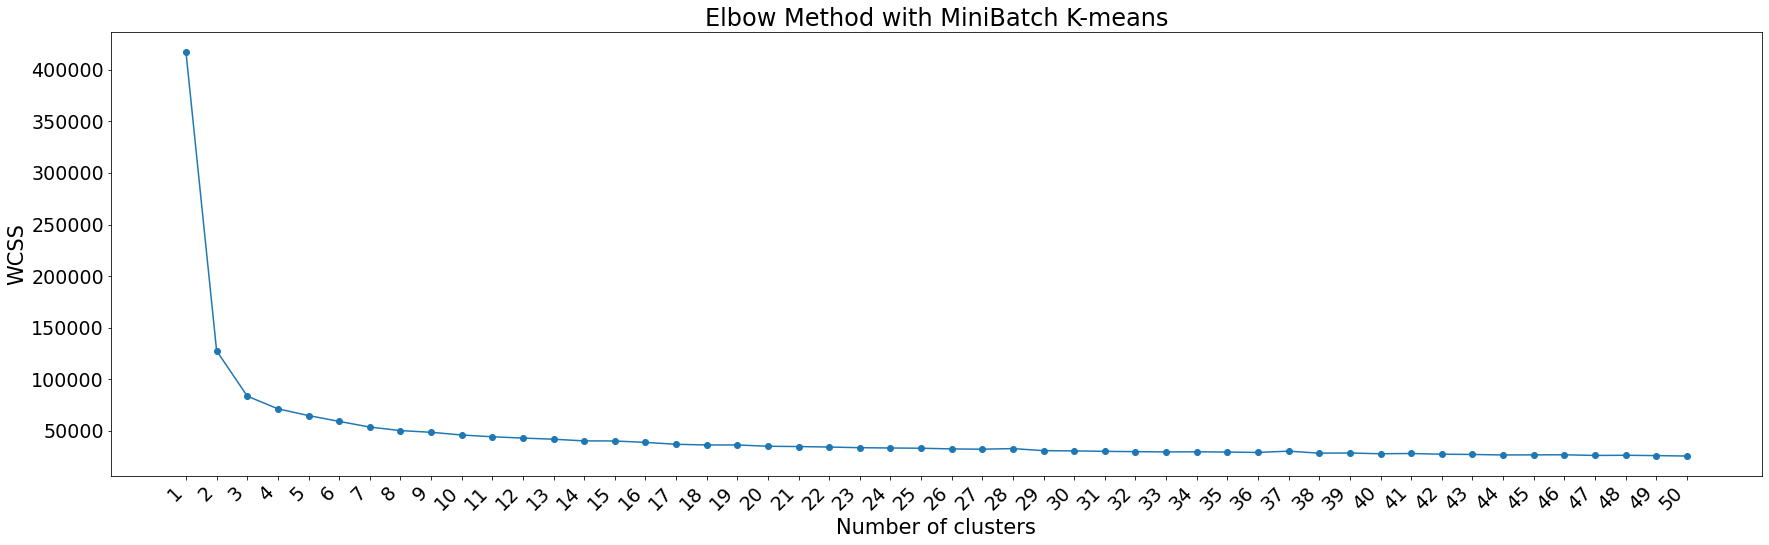

In [21]:
# df1 = pd.read_csv(os.path.join(data, "prep_origin_scd.csv"))
# df1 = df1.drop(columns=['Unnamed: 0'])

df_tmp = df_scd.copy()
# na_cols = df_tmp.isna().sum()
# na_cols = na_cols[na_cols > 0].sort_values(ascending=False)
# print("#### 결측값이 존재하는 컬럼:")
# print(na_cols)


# mean_survived = df_tmp.loc[df_tmp['death_label'] == 0, 'EFYN_day'].mean()
# mean_dead     = df_tmp.loc[df_tmp['death_label'] == 1, 'EFYN_day'].mean()
# mean_avg = (mean_survived + mean_dead) / 2
# df_tmp['EFYN_day'] = df_tmp['EFYN_day'].fillna(mean_avg)

data_for_clustering = df_tmp.drop(columns=['death_label'])

data = data_for_clustering

# Initialise list(WCSS)
wcss = []

# MiniBatch KMeans 클러스터링 실행 및 WCSS 계산
for i in range(1, 51):
    minibatch_kmeans = MiniBatchKMeans(n_clusters=i, batch_size=100, random_state=42)
    minibatch_kmeans.fit(data)
    wcss.append(minibatch_kmeans.inertia_)

font_size = 21
plt.rcParams.update({
    'font.size': font_size
    , 'axes.titlesize': font_size + 3
    , 'axes.labelsize': font_size
    , 'xtick.labelsize': font_size - 2
    , 'ytick.labelsize': font_size - 2
    , 'legend.fontsize': font_size - 2
})

# 그래프 생성
plt.figure(figsize=(25, 8))
plt.plot(range(1, 51), wcss, marker='o')
plt.title('Elbow Method with MiniBatch K-means')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')

# X축 레이블을 클러스터 수와 WCSS 값을 포함한 괄호 형식으로 출력
x_labels = [f'{i}' for i, w in enumerate(wcss, 1)]    #  \n ({w:.2f}) for i, w in enumerate(wcss, 1)
plt.xticks(range(1, 51), x_labels, rotation=45, ha='right')  # 49도 회전 및 오른쪽 정렬

# 그래프 표시
plt.tight_layout()
plt.savefig(os.path.join(save_dir, "WCSS_plot.png"))
plt.show()

In [22]:
wcss

[416936.51195827266,
 127559.82816952295,
 83622.69082728474,
 71279.34163336708,
 64758.00809416406,
 59111.88239223111,
 53609.32960153667,
 50202.994929858905,
 48527.73587803397,
 45918.6534928139,
 44184.565059059496,
 42923.38420805446,
 41816.14252327288,
 40203.09757402983,
 40106.406433601216,
 38743.08827337677,
 36912.963899322414,
 36233.84460261688,
 36250.76094386767,
 34983.7559800555,
 34711.968484512996,
 34235.89204322776,
 33601.819783559804,
 33309.32336152543,
 33085.2368026456,
 32414.189342546502,
 32138.591353015257,
 32724.18493379876,
 30724.765713894652,
 30482.081540763753,
 30071.129502871376,
 29748.978191965158,
 29514.921419261274,
 29607.088340417646,
 29359.011405589485,
 29014.070244665538,
 30239.490508963776,
 28283.86979553664,
 28470.896031756893,
 27716.129294486687,
 27982.828962729767,
 27270.715501769326,
 27050.872942524642,
 26547.387634353618,
 26636.644105055093,
 26729.376480018906,
 26088.019573217443,
 26253.452797227586,
 25932.1818748

In [30]:
# n_out = f'{out}/withPCA/PCA30/C27'
n_out = f'{out}/withPCA/PCA30/figs'
# n_out = f'{out}/PCA70'
# n_out = f'{out}/PCA90'
save_dir = n_out

In [83]:
# CLUSTERING :: HIERARCHICAL

Index(['death_label', 'PC1', 'PC2', 'PC3', 'PC4', 'PC5', 'PC6'], dtype='object') 7
Index(['PC1', 'PC2', 'PC3', 'PC4', 'PC5', 'PC6'], dtype='object') 6
Calculating Gower distance matrix...
Distance matrix calculation completed.
Performing hierarchical clustering...
Hierarchical clustering completed.
Calculating silhouette scores using precomputed Gower distance...
[n_clusters=2] Silhouette avg = 0.893, std_dev = 0.014
[n_clusters=3] Silhouette avg = 0.262, std_dev = 0.317
[n_clusters=4] Silhouette avg = 0.228, std_dev = 0.322
[n_clusters=5] Silhouette avg = 0.230, std_dev = 0.289
[n_clusters=6] Silhouette avg = 0.165, std_dev = 0.281
[n_clusters=7] Silhouette avg = 0.164, std_dev = 0.273
[n_clusters=8] Silhouette avg = 0.146, std_dev = 0.271
[n_clusters=9] Silhouette avg = 0.144, std_dev = 0.255
Best number of clusters based on STD DEVIATION: 2
Cluster number of the HIGHEST silhouette score: 2



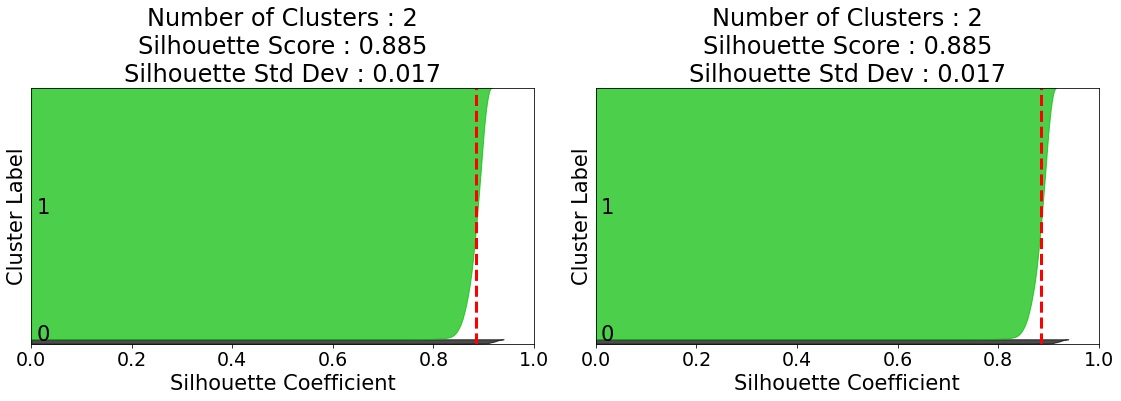

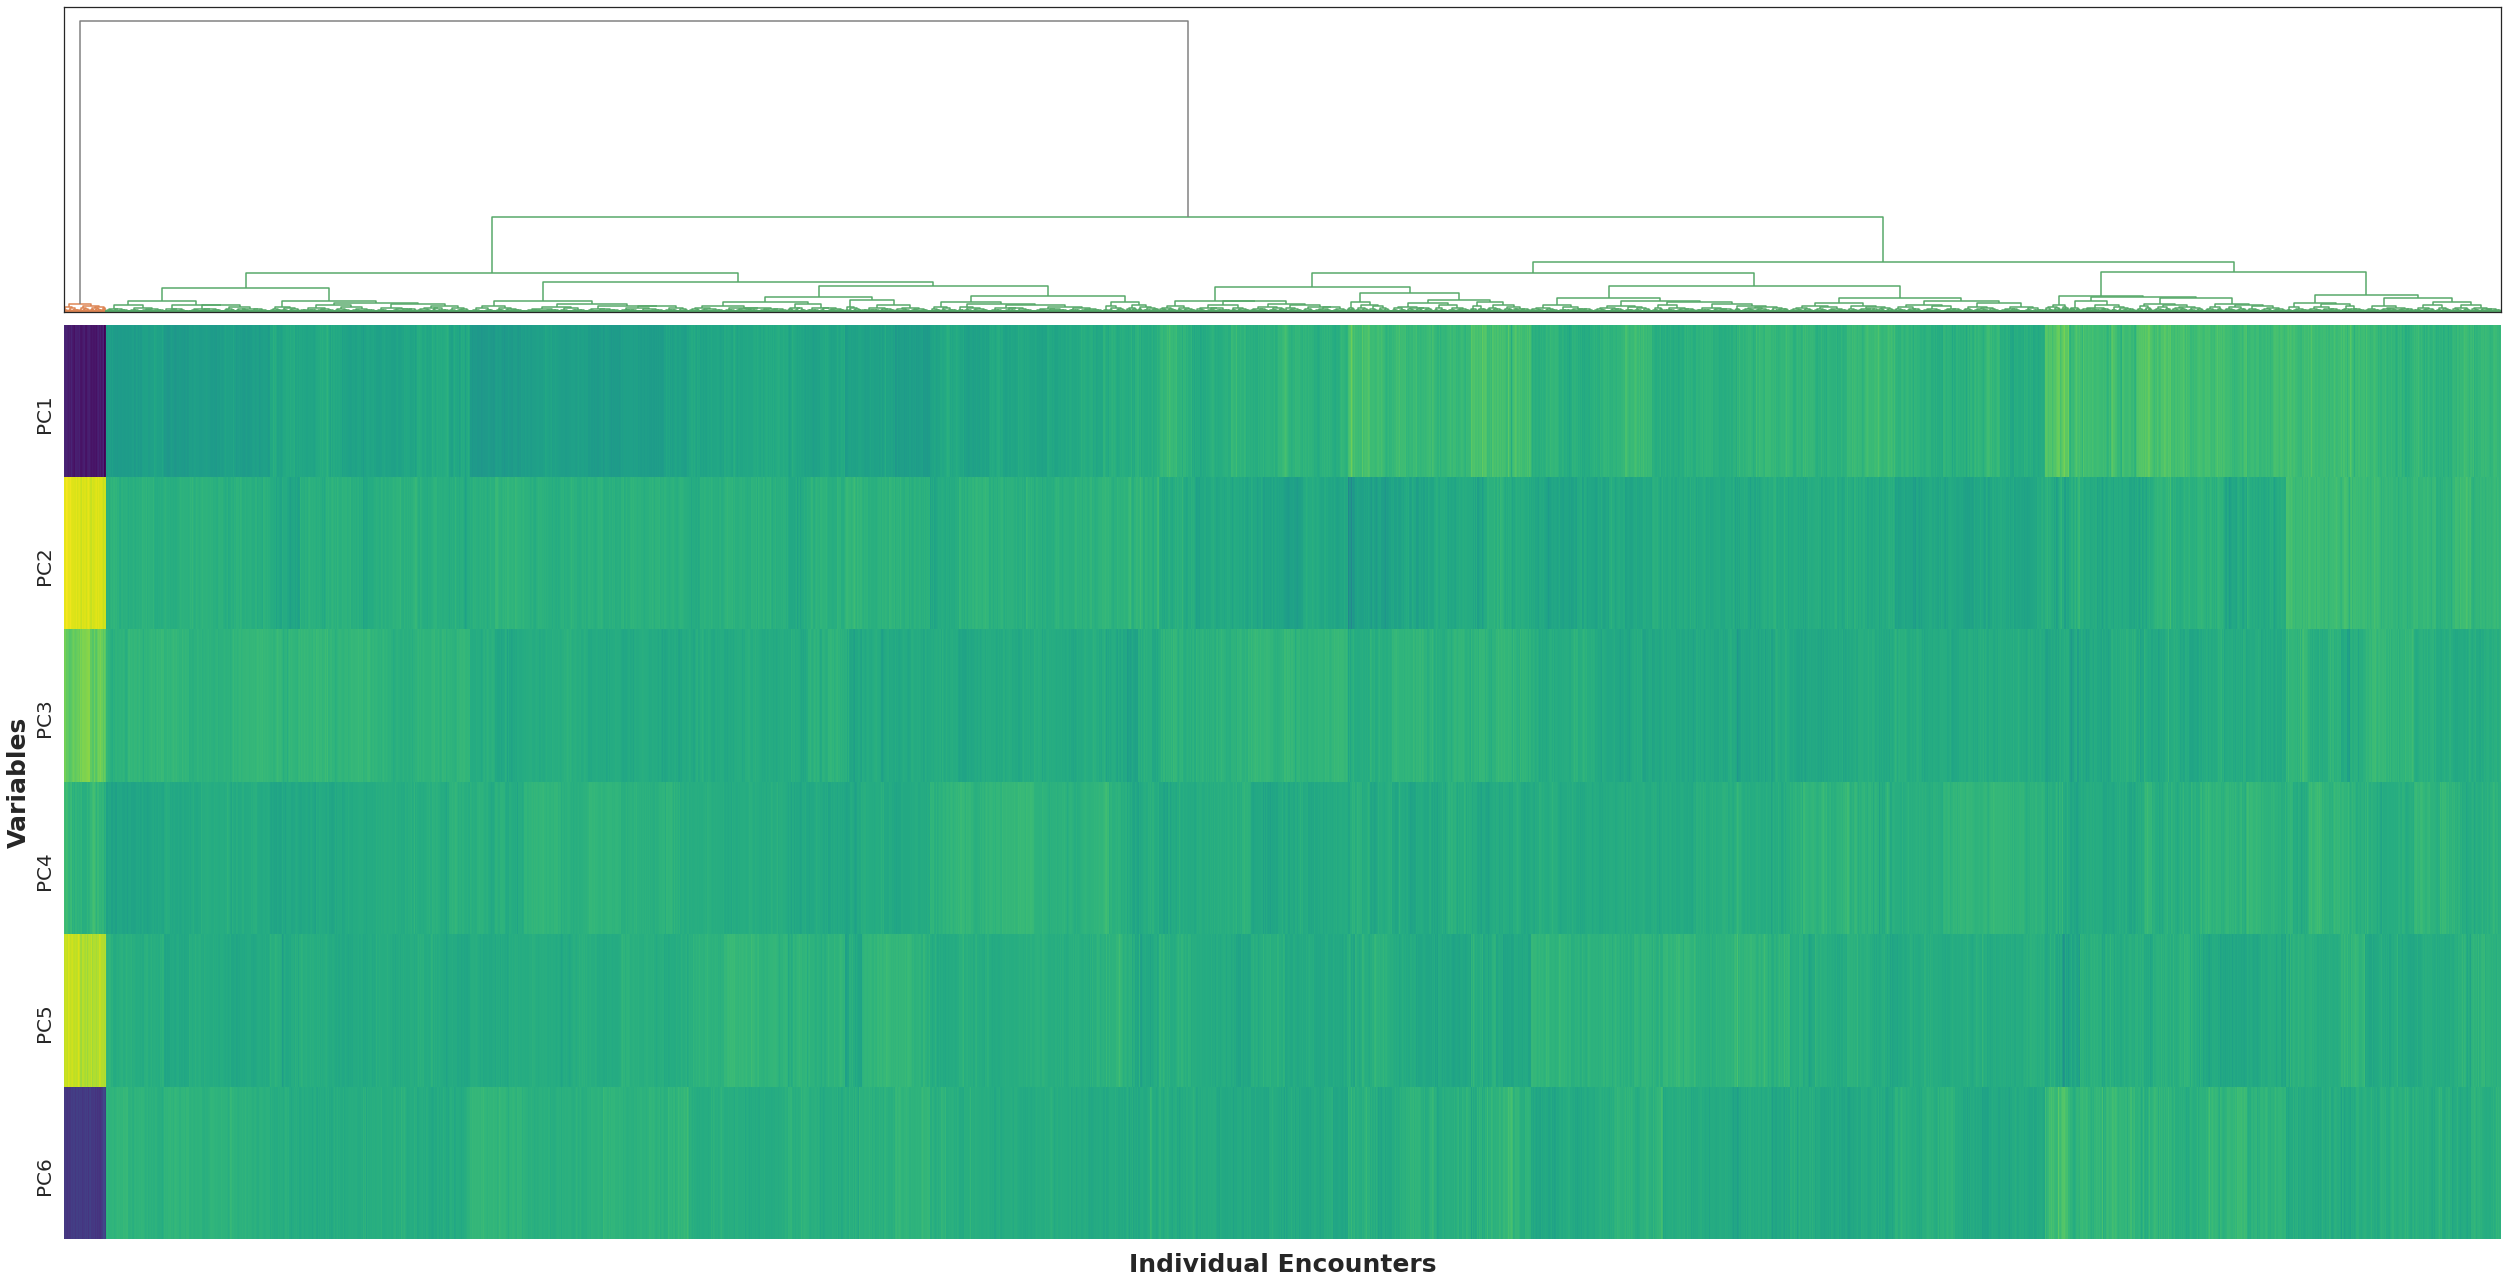

Clustering completed with SCALED data.
          death_label       PC1       PC2       PC3       PC4       PC5  \
idx_code                                                                  
0                   0 -0.445952  0.796068 -0.644476  0.971885 -0.599363   
1                   0  1.399960 -0.400933 -0.480073  0.207697 -0.003963   
2                   0 -0.485176  0.192993  0.297117 -0.251184 -0.404348   
3                   0  0.452304  0.297991  0.399171 -0.196712 -1.042254   
4                   0  0.522733 -0.500711 -0.952504  0.567902  0.077016   
...               ...       ...       ...       ...       ...       ...   
20408               0  0.073953  0.813402 -0.726491 -0.409746  0.441584   
20409               0  1.785806 -0.349752 -0.856092 -0.037723  0.093396   
20410               0 -0.923998 -0.309649 -0.071178 -0.569727 -0.088599   
20411               0 -0.918402  0.297851  1.820997 -0.507488  0.132138   
20412               0 -0.854064  0.309965  1.795812 -0.518372

In [31]:
data_for_clustering = df_scd.drop(columns=['death_label'])
print(df_scd.columns, len(df_scd.columns))
print(data_for_clustering.columns, len(data_for_clustering.columns))


# 사용자 정의 Gower 거리 계산 함수
def gower_distance_custom(X):
    """Custom Gower distance computation that ignores NaN values and does not normalize numerical differences."""
#     n_samples, n_features = X.shape
#     G = np.zeros((n_samples, n_samples))
    
#     for i in range(n_features):
#         feature = X[:, i]
#         if np.issubdtype(feature.dtype, np.number):
#             # 수치형 피쳐: 정규화 없이 절대 차이 사용
#             diff_matrix = np.abs(feature - feature.reshape(-1, 1))
#             diff_matrix[np.isnan(diff_matrix)] = 0  # NaN은 무시
#             G += diff_matrix
#         else:
#             # 범주형 피쳐: 동일하지 않으면 1, 동일하면 0
#             feature = feature.astype(str)
#             diff_matrix = (feature != feature.reshape(-1, 1)).astype(float)
#             diff_matrix[np.isnan(diff_matrix)] = 0  # NaN은 무시
#             G += diff_matrix
    
#     # 피쳐 수로 나누어 평균을 구함
#     G /= n_features
#     return G
    n_samples, n_features = X.shape
    
    # G[row, col]: 샘플 row와 col 간 '거리 합'
    G = np.zeros((n_samples, n_samples), dtype=float)
    # valid[row, col]: 결측 없이 비교가 가능한(둘 다 관측된) 변수 개수
    valid = np.zeros((n_samples, n_samples), dtype=float)
    
    for feat_idx in range(n_features):
        col_data = X[:, feat_idx]
        
        # 수치형 변수인지 판별
        if np.issubdtype(col_data.dtype, np.number):
            # 결측 여부
            not_nan_mask = ~np.isnan(col_data)
            
            for row in range(n_samples):
                for col in range(row + 1, n_samples):
                    # 둘 다 관측된 경우에만 거리 계산
                    if not_nan_mask[row] and not_nan_mask[col]:
                        dist_val = abs(col_data[row] - col_data[col])
                        G[row, col] += dist_val
                        G[col, row] += dist_val
                        valid[row, col] += 1
                        valid[col, row] += 1
                        
        else:
            # 범주형 변환 (NaN 처리 위해 object로)
            col_str = col_data.astype('O')  
            # non-null 마스크
            not_nan_mask = pd.notna(col_str)
            
            for row in range(n_samples):
                for col in range(row + 1, n_samples):
                    if not_nan_mask[row] and not_nan_mask[col]:
                        # 둘 다 관측이면
                        dist_val = 0.0 if col_str[row] == col_str[col] else 1.0
                        G[row, col] += dist_val
                        G[col, row] += dist_val
                        valid[row, col] += 1
                        valid[col, row] += 1
    
    # 유효 변수만큼 나누어 평균화
    for row in range(n_samples):
        for col in range(n_samples):
            if valid[row, col] > 0:
                G[row, col] /= valid[row, col]
            else:
                # valid=0인 경우, 둘 다 모든 변수 결측 -> 거리=0 (또는 np.nan)
                G[row, col] = 0.0
    
    return G

# 클러스터링 데이터를 넘파이 배열로 변환
X = data_for_clustering.to_numpy()

# 사용자 정의 Gower 거리 계산
print("Calculating Gower distance matrix...")
distance_matrix = gower_distance_custom(X)
print("Distance matrix calculation completed.")

# Condensed 거리 행렬 생성
distance_matrix_condensed = squareform(distance_matrix)  # 비대각 성분만 추출

# 계층적 클러스터링 수행
print("Performing hierarchical clustering...")
# Z_objects = linkage(distance_matrix_condensed, method='ward')
Z_objects = linkage(distance_matrix_condensed, method='ward')    # Ward method applied
print("Hierarchical clustering completed.")

# Z_objects를 저장
with open(os.path.join(save_dir, "Z_objects.pkl"), "wb") as f:
    pickle.dump(Z_objects, f)

# 실루엣 점수 및 표준 편차 계산
print("Calculating silhouette scores using precomputed Gower distance...")
silhouette_scores = []
silhouette_std_devs = []
range_n_clusters = list(range(2, 10))

for n_clusters in range_n_clusters:
    # 군집 레이블
    cluster_labels = fcluster(Z_objects, t=n_clusters, criterion='maxclust')
    
    # silhouette_samples() 호출 시 metric='precomputed' -> X가 '거리 행렬'이어야 함
    # distance_matrix: (n_samples x n_samples) 형태
    sil_values = silhouette_samples(distance_matrix, cluster_labels, metric='precomputed')
    sil_avg = np.mean(sil_values)
    
    # 각 클러스터별 평균을 구한 뒤 표준편차 계산
    cluster_means = []
    for label in np.unique(cluster_labels):
        cluster_means.append(np.mean(sil_values[cluster_labels == label]))
    sil_std_dev = np.std(cluster_means)
    
    silhouette_scores.append(sil_avg)
    silhouette_std_devs.append(sil_std_dev)
    
    print(f"[n_clusters={n_clusters}] Silhouette avg = {sil_avg:.3f}, std_dev = {sil_std_dev:.3f}")

best_n_clusters = range_n_clusters[np.argmin(silhouette_std_devs)]
highest_silhouette_clusters = range_n_clusters[np.argmax(silhouette_scores)]

# 편차가 가장 작은 클러스터 수 찾기
best_n_clusters = range_n_clusters[np.argmin(silhouette_std_devs)]
print("Best number of clusters based on STD DEVIATION:", best_n_clusters)
highest_silhouette_clusters = range_n_clusters[np.argmax(silhouette_scores)]
print("Cluster number of the HIGHEST silhouette score:", highest_silhouette_clusters)
print()


def visualize_silhouette_for_best_and_highest(best_n_clusters, highest_silhouette_clusters, X_features, data):
    cluster_lists = [best_n_clusters, highest_silhouette_clusters]
    n_cols = len(cluster_lists)
    fig, axs = plt.subplots(figsize=(8 * n_cols, 6), nrows=1, ncols=n_cols)
    
    for ind, n_cluster in enumerate(cluster_lists):
        cluster_labels = fcluster(Z_objects, t=n_cluster, criterion='maxclust')
        
        # NaN이 있는 샘플을 제외한 실루엣 점수 계산
        valid_idx = np.isfinite(X_features).all(axis=1)  # NaN이 없는 샘플 인덱스 추출
        X_valid = X_features[valid_idx]
        cluster_labels_valid = cluster_labels[valid_idx]
        
        # 유효한 샘플이 충분한지 확인
        if len(X_valid) == 0 or len(np.unique(cluster_labels_valid)) <= 1:
            print(f"Skipping silhouette calculation for n_clusters = {n_cluster} due to insufficient valid samples.")
            axs[ind].set_title(f"Number of Clusters : {n_cluster}\nNot enough valid data for silhouette")
            axs[ind].axis('off')  # 차트를 표시하지 않음
            continue
        
        sil_avg = silhouette_score(X_valid, cluster_labels_valid)
        sil_values = silhouette_samples(X_valid, cluster_labels_valid)
        sil_std_dev = np.std([np.mean(sil_values[cluster_labels_valid == label]) for label in np.unique(cluster_labels_valid)])
        
        y_lower = 10
        axs[ind].set_title(f'Number of Clusters : {n_cluster}\nSilhouette Score : {round(sil_avg, 3)}\nSilhouette Std Dev : {round(sil_std_dev, 3)}')
        axs[ind].set_xlabel("Silhouette Coefficient")
        axs[ind].set_ylabel("Cluster Label")
        axs[ind].set_xlim([0, 1])  # Silhouette score is always between -1 and 1; set lower bound to 0 to remove negative values.
        axs[ind].set_ylim([0, len(X_valid) + (n_cluster + 1) * 10])
        axs[ind].set_yticks([])  # Clear the y-axis labels / ticks
        axs[ind].set_xticks([0, 0.2, 0.4, 0.6, 0.8, 1])
        
        for i in range(n_cluster):
            ith_cluster_sil_values = sil_values[cluster_labels_valid == i + 1]
            ith_cluster_sil_values.sort()
            
            size_cluster_i = ith_cluster_sil_values.shape[0]
            y_upper = y_lower + size_cluster_i
            
            color = cm.nipy_spectral(float(i) / n_cluster)
            axs[ind].fill_betweenx(np.arange(y_lower, y_upper), 0, ith_cluster_sil_values,
                                   facecolor=color, edgecolor=color, alpha=0.7)
            axs[ind].text(0.01, y_lower + 0.5 * size_cluster_i, str(i))
            y_lower = y_upper + 10
            
        axs[ind].axvline(x=sil_avg, color="red", linestyle="--", linewidth=3)
        
    plt.tight_layout()
####    plt.savefig(os.path.join(save_dir, "visualize_silhouette_best_and_highest.png"))
    plt.show()

# 실루엣 스코어 시각화 및 저장
visualize_silhouette_for_best_and_highest(best_n_clusters
                                          , highest_silhouette_clusters
                                          , df_scd.to_numpy()
                                          , data
                                         )


# 시각화
sns.set(style="white")
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(35, 18), gridspec_kw={'height_ratios': [1, 3]})

# Dendrogram
threshold = Z_objects[-(best_n_clusters - 1), 2]
dendrogram(Z_objects
           , ax=ax1
           , orientation='top'
           , color_threshold=threshold
           , above_threshold_color='grey'
          )
ax1.set_xticks([])
ax1.set_yticks([])

sorted_idx = dendrogram(Z_objects, no_plot=True)['leaves']
data_sorted = data_for_clustering.iloc[sorted_idx]

# Heatmap
sns.heatmap(data_sorted.T, ax=ax2, cbar=False, cmap='viridis', yticklabels=True)
ax2.set_xlabel('Individual Encounters', fontsize=25, fontweight='bold')
ax2.set_ylabel('Variables', fontsize=25, fontweight='bold')
ax2.set_xticklabels([])
ax2.tick_params(axis='y', labelsize=20)
plt.tight_layout()

#### plt.savefig(os.path.join(save_dir, "cluster_analysis_scd.png"))
plt.show()

plt.close(fig)
#### print(f"Dendrogram + Heatmap saved: path : {save_dir}/cluster_analysis_scd.png")

# 클러스터 라벨을 데이터프레임에 추가
cluster_labels = fcluster(Z_objects, t=best_n_clusters, criterion='maxclust')
df_scd['Cluster_Labels'] = cluster_labels

# # 원래 index였던 pid를 다시 붙이기
# df_scd['pid'] = df.index
# df_scd.set_index('pid', inplace=True)

df_scd['death_label'] = df['death_label']

# df_scd['Cluster_Labels_orn'] = original_cluster_labels    # 특정 클러스터를 사용하는 경우 사용

# 결과 출력
print("Clustering completed with SCALED data.")
print(df_scd)

In [32]:
Z_dir_ = f'{Z_dir}/PCA30'

n_clusters = 27: Cluster sizes = {1: 353, 2: 805, 3: 1141, 4: 1072, 5: 683, 6: 837, 7: 975, 8: 699, 9: 1200, 10: 359, 11: 849, 12: 885, 13: 828, 14: 626, 15: 835, 16: 772, 17: 381, 18: 726, 19: 1025, 20: 987, 21: 641, 22: 895, 23: 202, 24: 1156, 25: 760, 26: 426, 27: 234}
For n_clusters = 27,
Average Silhouette_score : 0.0882,
std deviation: 0.1738



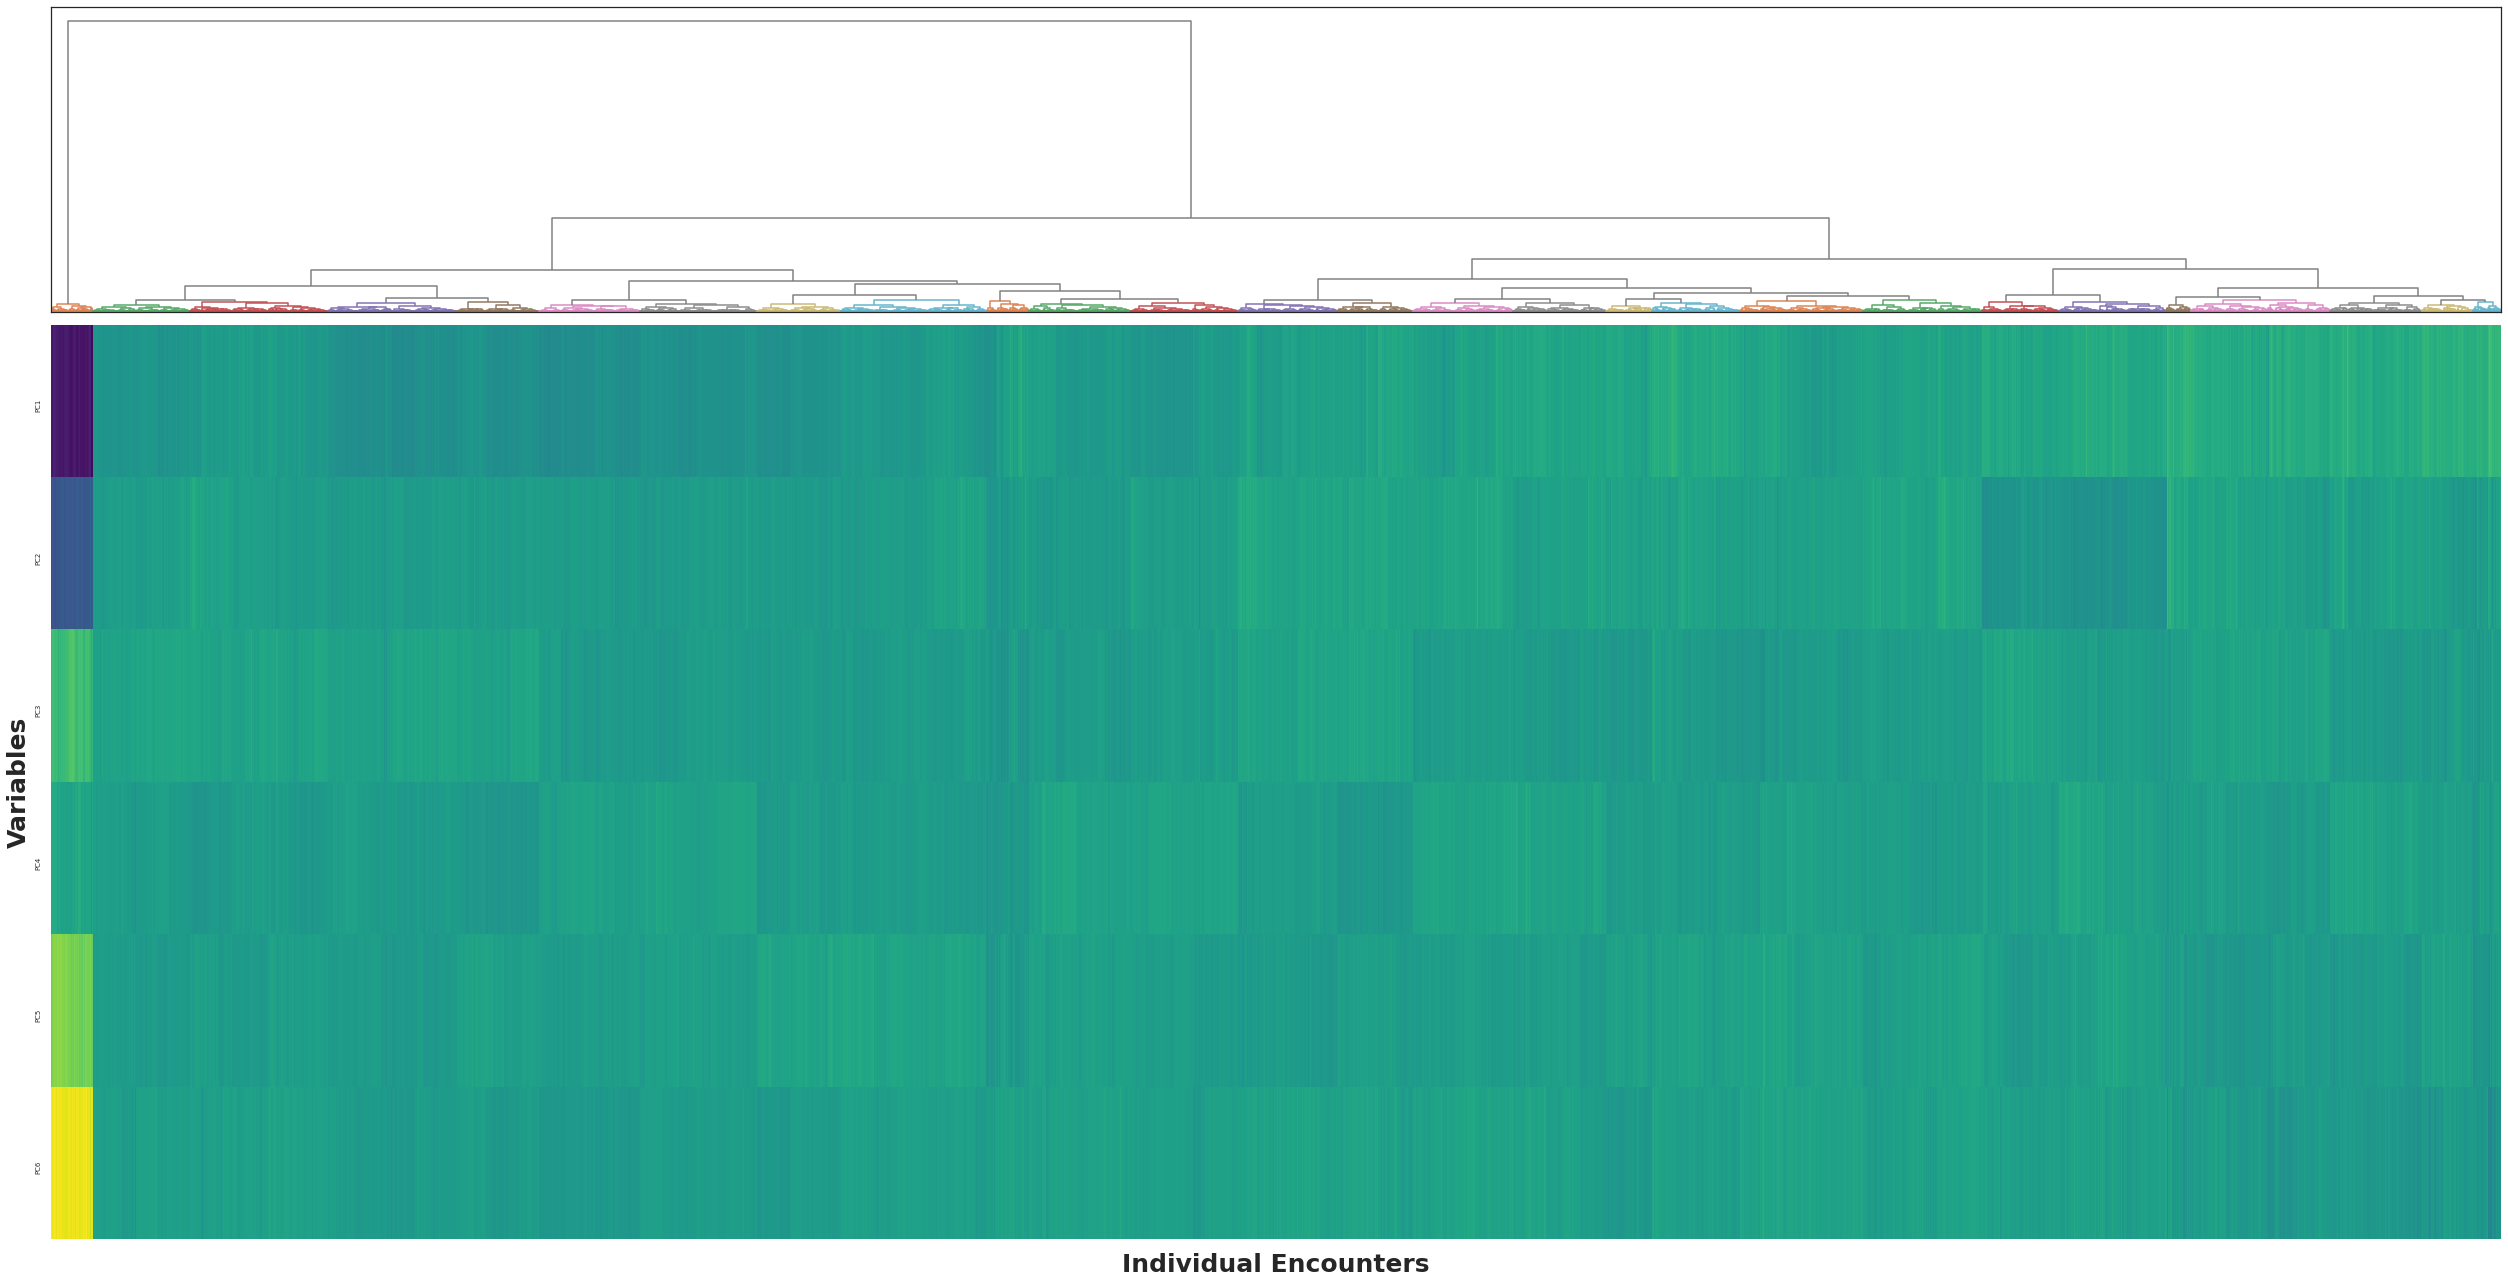

Dendrogram + Heatmap saved: path : /media/bami/d4960d77-e5f3-4877-a333-26e637be3a0e/JHA/24-07_nedis/KNN/Clustering/M15_dataset08/0531~/0711/WholeExp/withPCA/PCA30/C27/cluster_analysis_scd.png
Clustering completed with 3 clusters.
          death_label       PC1       PC2       PC3       PC4       PC5  \
idx_code                                                                  
0                   0 -0.445984 -0.795875 -0.644408  0.971977 -0.598970   
1                   0  1.399833  0.400483 -0.479963  0.207756 -0.003712   
2                   0 -0.485170 -0.192655  0.297198 -0.250979 -0.404558   
3                   0  0.452600 -0.299149  0.400413 -0.195556 -1.041745   
4                   0  0.522706  0.500295 -0.952892  0.567579  0.076620   
...               ...       ...       ...       ...       ...       ...   
20408               0  0.074108 -0.813933 -0.726094 -0.410020  0.441384   
20409               0  1.785701  0.349272 -0.856073 -0.037888  0.093163   
20410               

In [48]:
## 재 클러스터링 with Z_objects : {n} Clusters
n_clusters = 27


# Z_objects 불러오기
with open(os.path.join(Z_dir_, "Z_objects.pkl"), "rb") as f:
    Z_objects = pickle.load(f)

# 데이터프레임에서 death_label 칼럼 제외
# data_for_clustering = df_scd.drop(columns=['death_label'])
data_for_clustering = df_scd.drop(columns=['death_label', 'Cluster_Labels'])

cluster_labels = fcluster(Z_objects, t=n_clusters, criterion='maxclust')

# 각 클러스터에 할당된 샘플 수 확인
unique, counts = np.unique(cluster_labels, return_counts=True)
cluster_counts = dict(zip(unique, counts))
print(f"n_clusters = {n_clusters}: Cluster sizes = {cluster_counts}")

# 실루엣 점수 계산
silhouette_vals = silhouette_samples(data_for_clustering.fillna(0), cluster_labels)  # 개별 샘플의 실루엣 점수 계산
silhouette_avg = np.mean(silhouette_vals)  # 전체 실루엣 점수의 평균
silhouette_std_dev = np.std([np.mean(silhouette_vals[cluster_labels == label]) for label in np.unique(cluster_labels)])

# 실루엣 점수 및 표준 편차 출력
print(f"For n_clusters = {n_clusters},\nAverage Silhouette_score : {silhouette_avg:.4f},\nstd deviation: {silhouette_std_dev:.4f}\n")

# 시각화
sns.set(style="white")
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(35, 18), gridspec_kw={'height_ratios': [1, 3]})

# Dendrogramme
threshold = Z_objects[-(n_clusters - 1), 2]
dendrogram(Z_objects
           , ax=ax1
           , orientation='top'
           , color_threshold=threshold
           , above_threshold_color='grey'
          )
ax1.set_xticks([])
ax1.set_yticks([])

sorted_idx = dendrogram(Z_objects, no_plot=True)['leaves']
data_sorted = data_for_clustering.iloc[sorted_idx]    ########

# Heatmap
sns.heatmap(data_sorted.T, ax=ax2, cbar=False, cmap='viridis', yticklabels=True)
ax2.set_xlabel('Individual Encounters', fontsize=25, fontweight='bold')
ax2.set_ylabel('Variables', fontsize=25, fontweight='bold')
ax2.set_xticklabels([])
ax2.tick_params(axis='y', labelsize=7)
plt.tight_layout()

plt.savefig(os.path.join(save_dir, "cluster_analysis_scd.png"))
plt.show()

plt.close(fig)
print(f"Dendrogram + Heatmap saved: path : {save_dir}/cluster_analysis_scd.png")

# 클러스터 라벨을 데이터프레임에 추가
df_scd['Cluster_Labels'] = cluster_labels

# # 원래 index였던 pid를 다시 붙이기
# df_scd['pid'] = df.index
# df_scd.set_index('pid', inplace=True)

df_scd['death_label'] = df['death_label']
# df_scd['Cluster_Labels_orn'] = original_cluster_labels    # 특정 클러스터를 사용하는 경우 사용

# 결과 출력
print("Clustering completed with 3 clusters.")
print(df_scd)

n_clusters = 27: Cluster sizes = {1: 353, 2: 805, 3: 1141, 4: 1072, 5: 683, 6: 837, 7: 975, 8: 699, 9: 1200, 10: 359, 11: 849, 12: 885, 13: 828, 14: 626, 15: 835, 16: 772, 17: 381, 18: 726, 19: 1025, 20: 987, 21: 641, 22: 895, 23: 202, 24: 1156, 25: 760, 26: 426, 27: 234}
For n_clusters = 27,
Average Silhouette_score : 0.0882,
std deviation: 0.1739



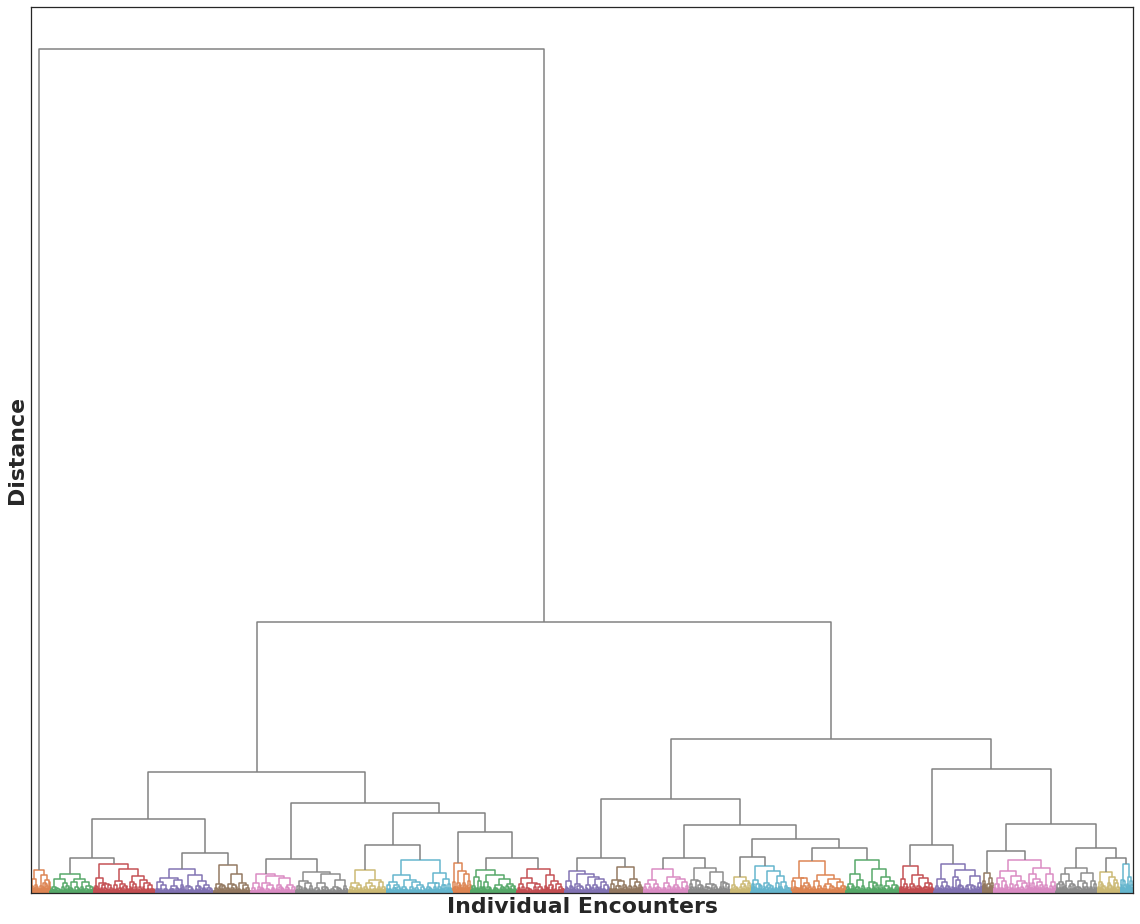

Dendrogram saved: path : /media/bami/JHA/24-07_nedis/KNN/Clustering/M15_dataset08/0531~/0711/WholeExp/withPCA/PCA30/figs/dendrogram_only_scd.tiff
Clustering completed with 27 clusters.
          death_label       PC1       PC2       PC3       PC4       PC5  \
idx_code                                                                  
0                   0 -0.445952  0.796068 -0.644476  0.971885 -0.599363   
1                   0  1.399960 -0.400933 -0.480073  0.207697 -0.003963   
2                   0 -0.485176  0.192993  0.297117 -0.251184 -0.404348   
3                   0  0.452304  0.297991  0.399171 -0.196712 -1.042254   
4                   0  0.522733 -0.500711 -0.952504  0.567902  0.077016   
...               ...       ...       ...       ...       ...       ...   
20408               0  0.073953  0.813402 -0.726491 -0.409746  0.441584   
20409               0  1.785806 -0.349752 -0.856092 -0.037723  0.093396   
20410               0 -0.923998 -0.309649 -0.071178 -0.569727 -0.

In [44]:
# Dendrogram REWORK ver.

## 재 클러스터링 with Z_objects : {n} Clusters
n_clusters = 27

# 저장 경로 직접 지정 (tiff)
save_path_dendrogram = os.path.join(n_out, "dendrogram_only_scd.tiff")

# Z_objects 불러오기
with open(os.path.join(Z_dir_, "Z_objects.pkl"), "rb") as f:
    Z_objects = pickle.load(f)



# 데이터프레임에서 clustering에 사용할 칼럼만 선택
data_for_clustering = df_scd.drop(columns=['death_label', 'Cluster_Labels'])

# 클러스터 라벨 생성
cluster_labels = fcluster(Z_objects, t=n_clusters, criterion='maxclust')

# 각 클러스터에 할당된 샘플 수 확인
unique, counts = np.unique(cluster_labels, return_counts=True)
cluster_counts = dict(zip(unique, counts))
print(f"n_clusters = {n_clusters}: Cluster sizes = {cluster_counts}")

# 실루엣 점수 계산
silhouette_vals = silhouette_samples(data_for_clustering.fillna(0), cluster_labels)
silhouette_avg = np.mean(silhouette_vals)
silhouette_std_dev = np.std([
    np.mean(silhouette_vals[cluster_labels == label])
    for label in np.unique(cluster_labels)
])

print(f"For n_clusters = {n_clusters},\nAverage Silhouette_score : {silhouette_avg:.4f},\nstd deviation: {silhouette_std_dev:.4f}\n")


# Dendrogram only
sns.set(style="white")

fig, ax = plt.subplots(figsize=(16, 13))

threshold = Z_objects[-(n_clusters - 1), 2]

dendrogram(
    Z_objects,
    ax=ax,
    orientation='top',
    color_threshold=threshold,
    above_threshold_color='grey',
    no_labels=True
)

ax.set_xlabel('Individual Encounters', fontsize=22, fontweight='bold')
ax.set_ylabel('Distance', fontsize=22, fontweight='bold')
ax.tick_params(axis='x', bottom=False, labelbottom=False)
# ax.tick_params(axis='y', labelsize=14)
ax.set_yticks([])

plt.tight_layout()
plt.savefig(save_path_dendrogram, dpi=300, format='tiff', bbox_inches='tight')
plt.show()
plt.close(fig)

print(f"Dendrogram saved: path : {save_path_dendrogram}")

# 클러스터 라벨을 데이터프레임에 추가
df_scd['Cluster_Labels'] = cluster_labels
df_scd['death_label'] = df['death_label']

print(f"Clustering completed with {n_clusters} clusters.")
print(df_scd)

In [ ]:
### Dendrogram reWork below -------->>

In [8]:
'''
base_dir = "/media/bami/JHA/24-07_nedis/KNN/Clustering/M15_dataset08/0531~/0711/WholeExp/withPCA/PCA30"
Z_path   = os.path.join(base_dir, "Z_objects.pkl")
X_path   = os.path.join(base_dir, "PCs_30pct_6.csv")

# Z_objects
with open(Z_path, "rb") as f:
    Z_objects = pickle.load(f)

# PCs dataframe (index 맞추려면 index_col=0 유지 권장)
df_scd = pd.read_csv(X_path)
if "idx_code" not in df_scd.columns:
    raise KeyError("No col_name 'idx_code' in PCs_30pct_6.csv.")
# df_scd["idx_code"] = df_scd["idx_code"].astype(str)
df_scd.set_index("idx_code", inplace=True)
df_scd
'''

,death_label,PC1,PC2,PC3,PC4,PC5,PC6
idx_code,,,,,,,
0,0,0.446061,-0.795315,0.644189,-0.972149,0.598073,-0.509970
1,0,-1.399798,0.399744,0.479963,-0.207851,0.003554,1.160349
2,0,0.485350,-0.192086,-0.297453,0.250621,0.404661,-0.322192
3,0,-0.453477,-0.301838,-0.402252,0.193576,1.040712,0.873670
4,0,-0.522709,0.499438,0.953517,-0.567054,-0.076114,-0.568916
...,...,...,...,...,...,...,...
20408,0,-0.074559,-0.814946,0.725391,0.410469,-0.441239,0.027338
20409,0,-1.785692,0.348476,0.856140,0.038161,-0.092661,0.593057
20410,0,0.924886,0.311480,0.072088,0.570288,0.090851,0.095990


               PC1       PC2       PC3       PC4       PC5       PC6
idx_code                                                            
0         0.446061 -0.795315  0.644189 -0.972149  0.598073 -0.509970
1        -1.399798  0.399744  0.479963 -0.207851  0.003554  1.160349
2         0.485350 -0.192086 -0.297453  0.250621  0.404661 -0.322192
3        -0.453477 -0.301838 -0.402252  0.193576  1.040712  0.873670
4        -0.522709  0.499438  0.953517 -0.567054 -0.076114 -0.568916
...            ...       ...       ...       ...       ...       ...
20408    -0.074559 -0.814946  0.725391  0.410469 -0.441239  0.027338
20409    -1.785692  0.348476  0.856140  0.038161 -0.092661  0.593057
20410     0.924886  0.311480  0.072088  0.570288  0.090851  0.095990
20411     0.918528 -0.294311 -1.820769  0.507168 -0.133078 -0.911001
20412     0.854326 -0.305986 -1.795412  0.518248 -0.181536 -0.904002

[20352 rows x 6 columns]
n_clusters = 27: Cluster sizes = {1: 353, 2: 805, 3: 1141, 4: 1072, 5: 683, 6

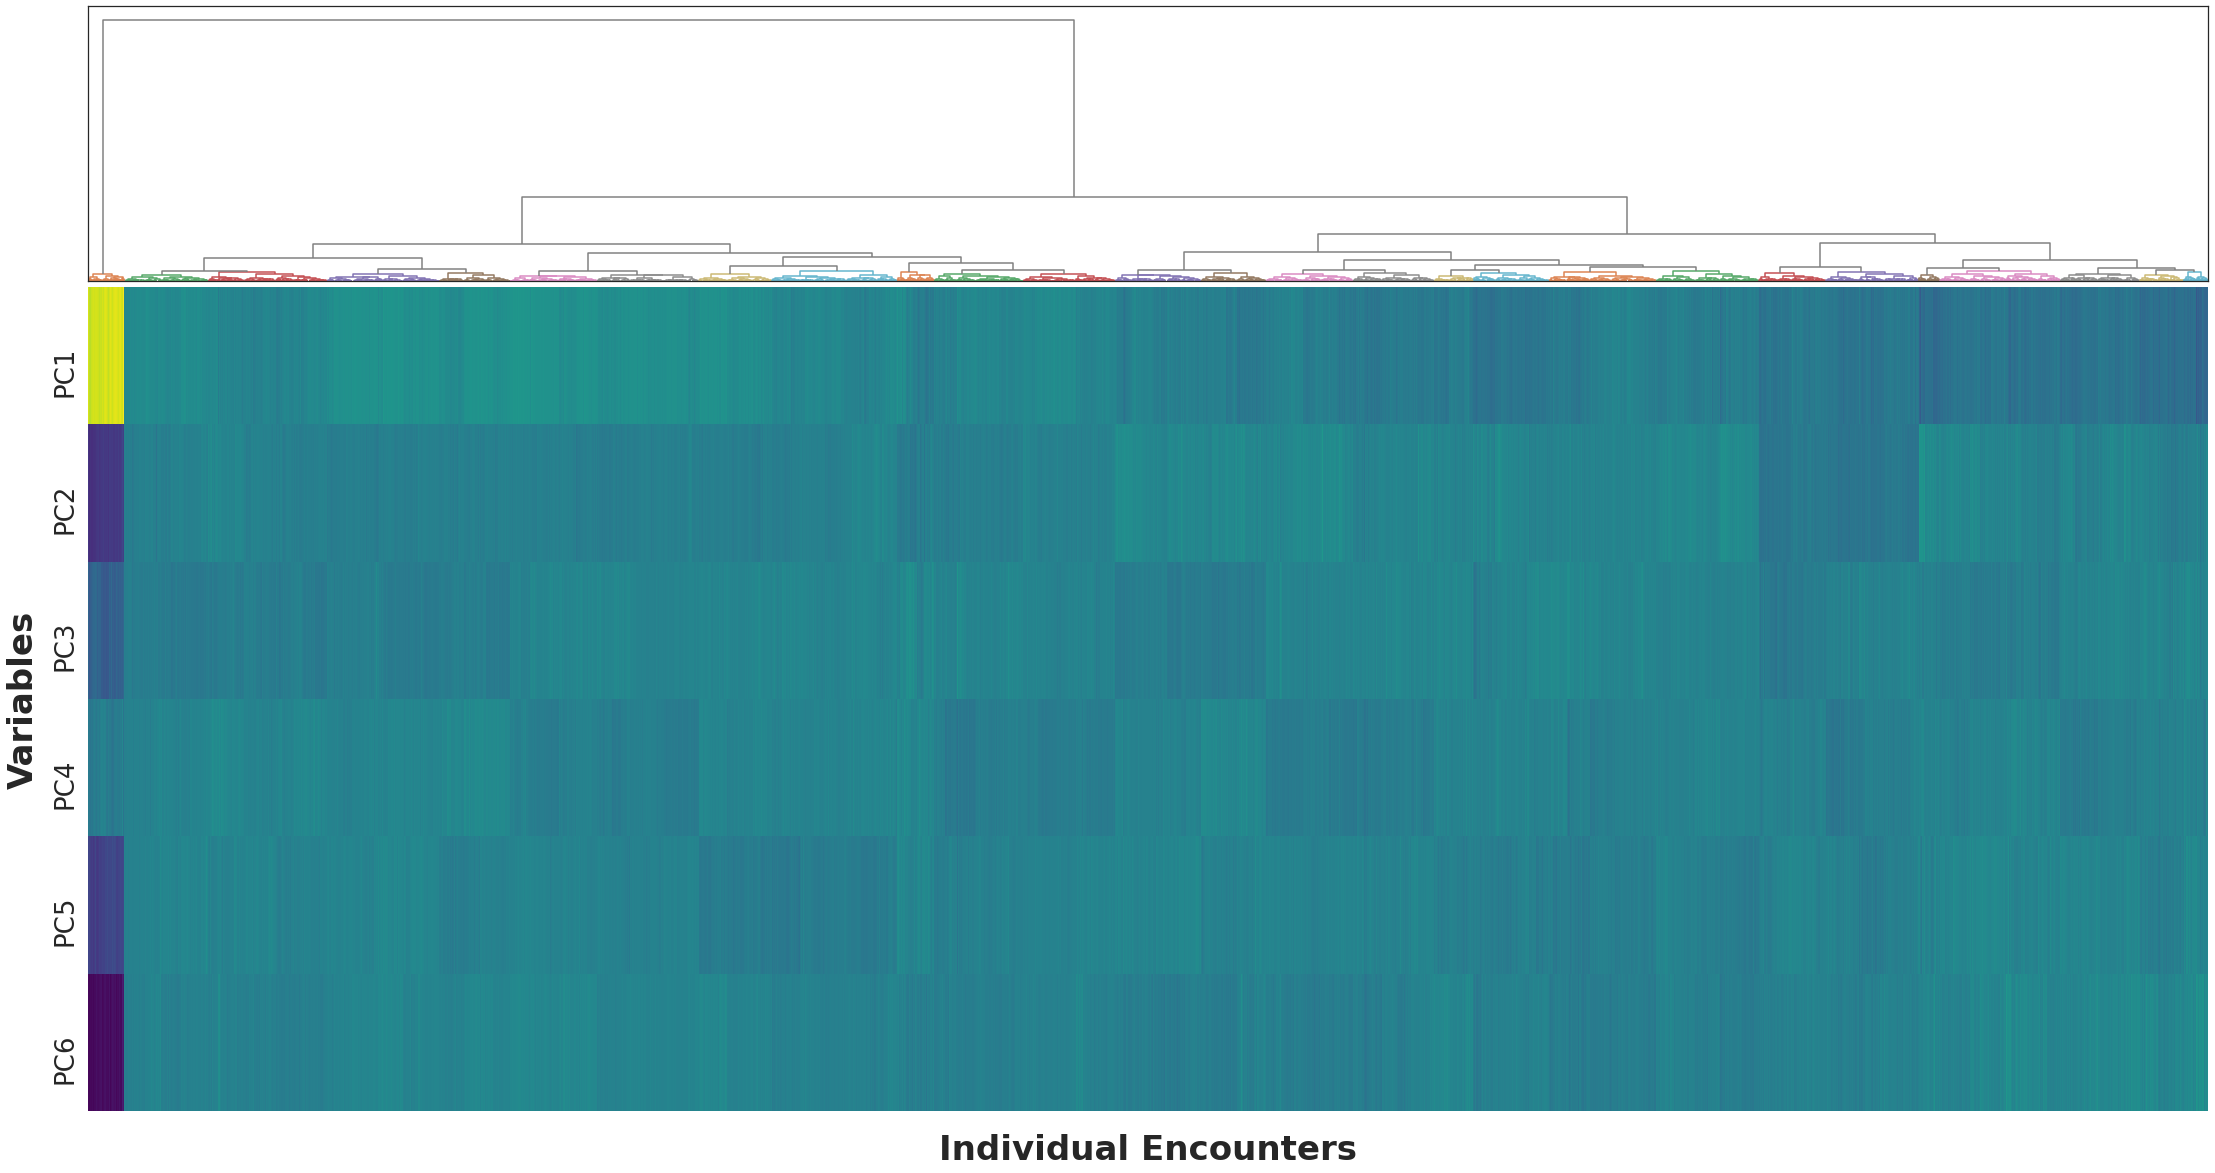

[Saved] /media/bami/JHA/24-07_nedis/KNN/Clustering/M15_dataset08/0531~/0711/WholeExp/withPCA/PCA30/figs/cluster_analysis_scd_27c_CMYK.tif


In [11]:
'''
from PIL import Image

data_for_clustering = df_scd.drop(columns=['death_label', 'Cluster_Labels'], errors='ignore')
print(data_for_clustering)



n_clusters = 27

cluster_labels = fcluster(Z_objects, t=n_clusters, criterion='maxclust')

unique, counts = np.unique(cluster_labels, return_counts=True)
cluster_counts = dict(zip(unique, counts))
print(f"n_clusters = {n_clusters}: Cluster sizes = {cluster_counts}")

silhouette_vals = silhouette_samples(data_for_clustering.fillna(0), cluster_labels)
silhouette_avg = np.mean(silhouette_vals)
silhouette_std_dev = np.std([np.mean(silhouette_vals[cluster_labels == label])
                             for label in np.unique(cluster_labels)])
print(f"For n_clusters = {n_clusters},\nAverage Silhouette_score : {silhouette_avg:.4f},\nstd deviation: {silhouette_std_dev:.4f}\n")

# ---- Plot (글자 더 크게 + dendrogram y축 완전 제거)
sns.set(style="white")

plt.rcParams.update({
    "font.size": 30,
    "axes.titlesize": 34,
    "axes.labelsize": 34,
    "xtick.labelsize": 24,
    "ytick.labelsize": 24,
})

fig, (ax1, ax2) = plt.subplots(
    2, 1,
    figsize=(31.5, 16.5),
    gridspec_kw={'height_ratios': [1, 3], "hspace": 0.01}
)

# Dendrogram
threshold = Z_objects[-(n_clusters - 1), 2]
dendrogram(
    Z_objects,
    ax=ax1,
    orientation='top',
    color_threshold=threshold,
    above_threshold_color='grey'
)

# dendrogram: ticks 제거 + y축 자체 제거 + title 제거
ax1.set_title("")
# ax1.set_xlabel("Individual Encounters", fontweight='bold', labelpad=10)
ax1.set_xlabel("")
ax1.set_xticks([])
ax1.set_yticks([])
ax1.set_ylabel("")
# ax1.yaxis.set_visible(False)   # <<<< y축 완전 제거 (spine/ticks 포함)

# sorted
sorted_idx = dendrogram(Z_objects, no_plot=True)['leaves']
data_sorted = data_for_clustering.iloc[sorted_idx]

# Heatmap
sns.heatmap(
    data_sorted.T,
    ax=ax2,
    cbar=False,
    cmap='viridis',
    yticklabels=True
)

# heatmap: title 제거
ax2.set_title("")
ax2.set_xlabel("Individual Encounters", fontweight='bold', labelpad=12)
ax2.set_ylabel("Variables", fontweight='bold', labelpad=12)
ax2.set_xticklabels([])

# y tick 글자 더 크게 (PC1~PC6 같은 라벨)
ax2.tick_params(axis='y', labelsize=26)

# subplot 여백 최소 + 두 plot 거의 붙이기
fig.subplots_adjust(left=0.06, right=0.995, top=0.99, bottom=0.06, hspace=0.01)

# ---- 저장: TIFF 300dpi + LZW, CMYK 변환
save_dir = os.path.join(base_dir, "figs")
os.makedirs(save_dir, exist_ok=True)

rgb_path  = os.path.join(save_dir, f"cluster_analysis_scd_{n_clusters}c_RGB.tif")
cmyk_path = os.path.join(save_dir, f"cluster_analysis_scd_{n_clusters}c_CMYK.tif")

fig.savefig(
    rgb_path,
    format="tiff",
    dpi=300,
    bbox_inches="tight",
    pil_kwargs={"compression": "tiff_lzw"}
)

plt.show()
plt.close(fig)

Image.MAX_IMAGE_PIXELS = None
Image.open(rgb_path).convert("CMYK").save(
    cmyk_path, dpi=(300, 300), compression="tiff_lzw"
)

print(f"[Saved] {cmyk_path}")
'''

In [18]:
'''# {n} Level까지만 클러스터링
k_ = 2

data_for_clustering = df_scd.drop(columns=list(mortality))
print(df_scd.columns)
print(data_for_clustering.columns)

with open(os.path.join(save_dir, "Z_objects.pkl"), "rb") as f:
    Z_objects = pickle.load(f)

# 2nd Level 결과추출
cluster_labels_level_2 = fcluster(Z_objects, t=k_, criterion='maxclust')
print("Cluster labels at level 2:", cluster_labels_level_2)

# Cluster_label 추가
df_scd['Cluster_Labels'] = cluster_labels_level_2
print("Clustering completed with SCALED data.")
print(df_scd[['Cluster_Labels']])

# 시각화
sns.set(style="white")
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(35, 18), gridspec_kw={'height_ratios': [1, 3]})

# 계층적 클러스터링의 덴드로그램 그리기
# Z_objects 로드 (이전에 저장한 Z_objects.pkl을 사용하셨다면 해당 파일 로드 필요)
with open(os.path.join(save_dir, "Z_objects.pkl"), "rb") as f:
    Z_objects = pickle.load(f)

# 2층 클러스터링 결과에 따른 threshold 계산
threshold = Z_objects[-2, 2]  # 2단계 클러스터링의 컷오프 높이 추출
dendrogram(Z_objects, ax=ax1, orientation='top', color_threshold=threshold, above_threshold_color='grey')
ax1.axhline(y=threshold, color='r', linestyle='--')  # 2층 분할 위치에 선 그리기
ax1.set_xticks([])
ax1.set_yticks([])

# 클러스터링 결과에 따른 데이터 정렬_
sorted_idx = dendrogram(Z_objects, no_plot=True)['leaves']
data_sorted = data_for_clustering.iloc[sorted_idx]  # 클러스터링 순서대로 데이터 정렬

# 히트맵 그리기
sns.heatmap(data_sorted.T, ax=ax2, cbar=False, cmap='viridis', yticklabels=True)
ax2.set_xlabel('Individual Encounters', fontsize=25, fontweight='bold')
ax2.set_ylabel('Variables', fontsize=25, fontweight='bold')
ax2.set_xticklabels([])
ax2.tick_params(axis='y', labelsize=20)
plt.tight_layout()

# 결과 저장 및 보여주기
plt.savefig(os.path.join(save_dir, "0814_cluster_analysis_scd.png"))
plt.show()

plt.close(fig)
print(f"Dendrogram + Heatmap saved: path : {save_dir}/0814_cluster_analysis_scd.png")

# 결과 저장
df_scd.to_csv(os.path.join(save_dir, "df_scd_clustered_level_2.csv"))'''

'# {n} Level까지만 클러스터링\nk_ = 2\n\ndata_for_clustering = df_scd.drop(columns=list(mortality))\nprint(df_scd.columns)\nprint(data_for_clustering.columns)\n\nwith open(os.path.join(save_dir, "Z_objects.pkl"), "rb") as f:\n    Z_objects = pickle.load(f)\n\n# 2nd Level 결과추출\ncluster_labels_level_2 = fcluster(Z_objects, t=k_, criterion=\'maxclust\')\nprint("Cluster labels at level 2:", cluster_labels_level_2)\n\n# Cluster_label 추가\ndf_scd[\'Cluster_Labels\'] = cluster_labels_level_2\nprint("Clustering completed with SCALED data.")\nprint(df_scd[[\'Cluster_Labels\']])\n\n# 시각화\nsns.set(style="white")\nfig, (ax1, ax2) = plt.subplots(2, 1, figsize=(35, 18), gridspec_kw={\'height_ratios\': [1, 3]})\n\n# 계층적 클러스터링의 덴드로그램 그리기\n# Z_objects 로드 (이전에 저장한 Z_objects.pkl을 사용하셨다면 해당 파일 로드 필요)\nwith open(os.path.join(save_dir, "Z_objects.pkl"), "rb") as f:\n    Z_objects = pickle.load(f)\n\n# 2층 클러스터링 결과에 따른 threshold 계산\nthreshold = Z_objects[-2, 2]  # 2단계 클러스터링의 컷오프 높이 추출\ndendrogram(Z_objects, ax=ax1, or

In [49]:
# df_scd.to_csv(os.path.join(out_0830, f"df\_scd_{best_n_clusters}clustered.csv"))
df_scd.to_csv(os.path.join(save_dir, f"df_scd_{n_clusters}clustered.csv"))

In [50]:
print(df_scd['Cluster_Labels'].value_counts().sort_index())
print(df_scd.isnull().sum())

1      353
2      805
3     1141
4     1072
5      683
6      837
7      975
8      699
9     1200
10     359
11     849
12     885
13     828
14     626
15     835
16     772
17     381
18     726
19    1025
20     987
21     641
22     895
23     202
24    1156
25     760
26     426
27     234
Name: Cluster_Labels, dtype: int64
death_label       0
PC1               0
PC2               0
PC3               0
PC4               0
PC5               0
PC6               0
Cluster_Labels    0
dtype: int64


In [51]:
df_scd.to_csv(os.path.join(save_dir, "df_scd_clustered.csv"))

In [52]:
## Merge Cluster_Labels to original dataframe
df_combined = df.merge(df_scd[['Cluster_Labels']]
                       , left_index=True, right_index=True
                       , how='left'
                      )
df_combined

,sex_sys_val,birthdt,bird,admd,apgs1,apgs5,bwei,mage,gran,parn,...,ntetoy_1,iperr_1,iperr_2,iperr_3,iperr_4,iperroy_1,iperroy_4,iperroy_3,iperroy_2,Cluster_Labels
idx_code,,,,,,,,,,,,,,,,,,,,,
0,1,2013-12-18,2013-12-18,2013-12-18,4.0,5.0,1350,29,1,0,...,0,1,0,0,0,1,0,0,0,11
1,1,2013-11-15,2013-11-15,2013-11-15,4.0,5.0,790,35,1,0,...,0,1,0,0,0,1,0,0,0,17
2,1,2013-11-15,2013-11-15,2013-11-15,5.0,6.0,1400,26,1,0,...,0,1,0,0,0,1,0,0,0,3
3,1,2013-11-15,2013-11-15,2013-11-15,6.0,7.0,1340,26,1,0,...,0,1,0,0,0,1,0,0,0,24
4,1,2013-11-11,2013-11-11,2013-11-11,4.0,5.0,1240,36,4,1,...,0,1,0,0,0,1,0,0,0,19
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20408,1,2022-11-28,2022-11-28,2022-11-28,5.0,8.0,1350,23,1,0,...,0,1,0,0,0,1,0,0,0,11
20409,1,2022-12-27,2022-12-27,2022-12-27,4.0,7.0,860,38,3,1,...,0,1,0,0,0,1,0,0,0,18
20410,0,2022-12-01,2022-12-01,2022-12-01,5.0,7.0,1910,30,2,0,...,0,1,0,0,0,1,0,0,0,9


In [53]:
df_combined.to_csv(os.path.join(save_dir, "KNN_df_combined.csv"))

In [108]:
# WILCOXON TEST

# Declare input data
input_df = df_combined

# 고유 클러스터 값과 클러스터 수 계산
unique_clusters = input_df['Cluster_Labels'].unique()
num_clusters = len(unique_clusters)

# 통계 및 p-값 저장용 DataFrame 생성
stats_df = pd.DataFrame()
p_values_df = pd.DataFrame()

# 각 클러스터 및 변수에 대한 계산
for i in unique_clusters:
    cluster_data = input_df[input_df['Cluster_Labels'] == i]
    outside_data = input_df[input_df['Cluster_Labels'] != i]
    stats = {}
    p_values = {}

    for column in input_df.columns[:-1]:  # 마지막 'Cluster_Labels' 제외
        if column != 'Cluster_Labels' and is_numeric_dtype(input_df[column]):
            valid_cluster_data = cluster_data[column].dropna()
            valid_outside_data = outside_data[column].dropna()

            # 두 집단 모두에서 유효한 데이터가 존재하고 모든 값이 같지 않을 때만 계산
            if len(valid_cluster_data) > 0 and len(valid_outside_data) > 0 and pd.concat([valid_cluster_data, valid_outside_data]).nunique() > 1:
                u_stat, p_value = mannwhitneyu(valid_cluster_data, valid_outside_data, alternative='two-sided')
                mean_val = valid_cluster_data.mean()
                std_dev = valid_cluster_data.std()

                # 결과 저장
                stats[column] = f"{mean_val:.4f} ± {std_dev:.4f}"
                if p_value < 0.01:
                    formatted_p_value = f"{p_value:.4e}" if p_value < 0.0001 else f"{p_value:.4f}"
                    p_values[column] = formatted_p_value
                else:
                    p_values[column] = "n.s."
            else:
                stats[column] = "NaN ± NaN"
                p_values[column] = "n.s."

    stats_df[f'Cluster {i}'] = pd.Series(stats)
    p_values_df[f'Cluster {i}'] = pd.Series(p_values)

# 결과를 DataFrame으로 결합
combined_df = pd.DataFrame()
for i in unique_clusters:
    combined_stats = stats_df[f'Cluster {i}'] + " (" + p_values_df[f'Cluster {i}'] + ")"
    combined_df[f'Cluster {i}'] = combined_stats

# Cluster 열을 이름을 기준으로 정렬
combined_df = combined_df.reindex(sorted(combined_df.columns), axis=1)

# 결과 출력
print("Combined Mean, Standard Deviation and P-values:")
print(combined_df)

Combined Mean, Standard Deviation and P-values:
                                     Cluster 1  \
sex_sys_val       0.4632 ± 0.4987 (1.8092e-21)   
apgs1             5.9150 ± 1.7800 (0.0000e+00)   
apgs5             7.8937 ± 1.2993 (0.0000e+00)   
bwei         1290.1546 ± 200.2696 (0.0000e+00)   
mage                   33.4123 ± 4.3265 (n.s.)   
...                                        ...   
iperr_4                 0.0000 ± 0.0000 (n.s.)   
iperroy_1         0.9965 ± 0.0590 (1.5977e-51)   
iperroy_4         0.0004 ± 0.0190 (6.6493e-08)   
iperroy_3         0.0030 ± 0.0548 (1.4684e-40)   
iperroy_2         0.0001 ± 0.0110 (1.0079e-05)   

                                    Cluster 2  \
sex_sys_val      0.5474 ± 0.4979 (1.4545e-05)   
apgs1            2.8379 ± 1.7627 (0.0000e+00)   
apgs5            5.0526 ± 2.2205 (0.0000e+00)   
bwei         815.7654 ± 301.8103 (0.0000e+00)   
mage                  33.2194 ± 4.5537 (n.s.)   
...                                       ...   
iperr_4 

In [96]:
'''
# Wilcoxon test :: features --> P-Value 순으로 정렬

unique_clusters = df_combined['Cluster_Labels'].unique()

# 통계 및 p-값 저장용 DataFrame 생성
stats_df = pd.DataFrame()
p_values_df = pd.DataFrame()

# 각 클러스터 및 변수에 대한 계산
for cluster in unique_clusters:
    cluster_data = df_combined[df_combined['Cluster_Labels'] == cluster]
    outside_data = df_combined[df_combined['Cluster_Labels'] != cluster]
    
    for column in df_combined.columns[:-1]:  # 마지막 'Cluster_Labels' 제외
        if column != 'Cluster_Labels' and is_numeric_dtype(df_combined[column]):
            valid_cluster_data = cluster_data[column].dropna()
            valid_outside_data = outside_data[column].dropna()

            # 두 집단 모두에서 유효한 데이터가 존재하고 모든 값이 같지 않을 때만 계산
            if len(valid_cluster_data) > 0 and len(valid_outside_data) > 0 and pd.concat([valid_cluster_data, valid_outside_data]).nunique() > 1:
                u_stat, p_value = mannwhitneyu(valid_cluster_data, valid_outside_data, alternative='two-sided')
                mean_val = valid_cluster_data.mean()
                std_dev = valid_cluster_data.std()

                # 결과 저장
                stats_df.loc[column, f'Cluster {cluster}'] = f"{mean_val:.4f} ± {std_dev:.4f}"
                p_values_df.loc[column, f'Cluster {cluster}'] = p_value
            else:
                stats_df.loc[column, f'Cluster {cluster}'] = "NaN ± NaN"
                p_values_df.loc[column, f'Cluster {cluster}'] = float('nan')

# 각 특성별 최소 p-value 계산
p_values_df['min_p_value'] = p_values_df.min(axis=1)

# p-value를 기준으로 행 정렬
p_values_df = p_values_df.sort_values(by='min_p_value')

# 정렬된 순서대로 최종 DataFrame 구성
combined_df = pd.DataFrame()
for column in p_values_df.columns[:-1]:  # 'min_p_value' 제외
    formatted_values = stats_df[column].reindex(p_values_df.index).astype(str) + " (" + p_values_df[column].reindex(p_values_df.index).apply(lambda x: f"{x:.4e}" if x < 0.0001 else f"{x:.4f}" if x == x else "n.s.").astype(str) + ")"
    combined_df[column] = formatted_values

# 결과 출력
print("Combined Mean, Standard Deviation and P-values (sorted by feature min p-value):")
print(combined_df)
'''

'\n# Wilcoxon test :: features --> P-Value 순으로 정렬\n\nunique_clusters = df_combined[\'Cluster_Labels\'].unique()\n\n# 통계 및 p-값 저장용 DataFrame 생성\nstats_df = pd.DataFrame()\np_values_df = pd.DataFrame()\n\n# 각 클러스터 및 변수에 대한 계산\nfor cluster in unique_clusters:\n    cluster_data = df_combined[df_combined[\'Cluster_Labels\'] == cluster]\n    outside_data = df_combined[df_combined[\'Cluster_Labels\'] != cluster]\n    \n    for column in df_combined.columns[:-1]:  # 마지막 \'Cluster_Labels\' 제외\n        if column != \'Cluster_Labels\' and is_numeric_dtype(df_combined[column]):\n            valid_cluster_data = cluster_data[column].dropna()\n            valid_outside_data = outside_data[column].dropna()\n\n            # 두 집단 모두에서 유효한 데이터가 존재하고 모든 값이 같지 않을 때만 계산\n            if len(valid_cluster_data) > 0 and len(valid_outside_data) > 0 and pd.concat([valid_cluster_data, valid_outside_data]).nunique() > 1:\n                u_stat, p_value = mannwhitneyu(valid_cluster_data, valid_outside_data, alter

In [57]:
combined_df.to_csv(os.path.join(save_dir, "KNN_df_combined_wilcoxon+p_val.csv")
                   , encoding='utf-8-sig'    # '±'표현을 위해 encoding='utf-8-sig' 사용
                  )

NameError: name 'combined_df' is not defined

In [54]:
## DEATH RATIO
# 'Cluster_Labels'와 'death_label' 확인
def calculate_positive_rate(ipt_df, ipt_col):
    # 'Cluster_Labels'와 ipt_col 확인
    if 'Cluster_Labels' in ipt_df.columns and ipt_col in ipt_df.columns:
        results_df = pd.DataFrame()

        # 각 클러스터의 Positive Rate 계산
        for i in sorted(ipt_df['Cluster_Labels'].unique()):  # Cluster_Labels 번호 순서대로 정렬
            cluster_data = ipt_df[ipt_df['Cluster_Labels'] == i]
            total_count = cluster_data.shape[0]
            positive_count = (cluster_data[ipt_col] == 1).sum()
            negative_count = (cluster_data[ipt_col] == 0).sum()

            # 칼럼 이름에서 언더바 이후를 제거
            display_col = ipt_col.split('_')[0]

            # Positive Rate 계산
            positive_rate = (positive_count / total_count) * 100

            # 결과 저장
            results_df.loc[f'Cluster {i}', 'Total'] = total_count
            results_df.loc[f'Cluster {i}', f'{display_col}_Pos'] = positive_count
            results_df.loc[f'Cluster {i}', f'{display_col}_Neg'] = negative_count
            results_df.loc[f'Cluster {i}', 'Positive Rate'] = f"{positive_rate:.2f}%"
            results_df.loc[f'Cluster {i}', f'{display_col}_Pos / Total'] = f"{positive_count} / {total_count}"

        # 결과 출력
        return results_df
    else:
        return f"Dataframe does not contain required columns 'Cluster_Labels' and '{ipt_col}'"


# iperr_3
# iperr_4

# ntet_1
# iperr_2
# death36
cmr = calculate_positive_rate(df_combined, 'death_label')
cmr1 = calculate_positive_rate(df_combined, 'ntet_1')
cmr2 = calculate_positive_rate(df_combined, 'iperr_2')
print(cmr, cmr1, cmr2)

             Total  death_Pos  death_Neg Positive Rate death_Pos / Total
Cluster 1    353.0      344.0        9.0        97.45%         344 / 353
Cluster 2    805.0        6.0      799.0         0.75%           6 / 805
Cluster 3   1141.0       13.0     1128.0         1.14%         13 / 1141
Cluster 4   1072.0        3.0     1069.0         0.28%          3 / 1072
Cluster 5    683.0        1.0      682.0         0.15%           1 / 683
Cluster 6    837.0        2.0      835.0         0.24%           2 / 837
Cluster 7    975.0        2.0      973.0         0.21%           2 / 975
Cluster 8    699.0        2.0      697.0         0.29%           2 / 699
Cluster 9   1200.0        9.0     1191.0         0.75%          9 / 1200
Cluster 10   359.0       24.0      335.0         6.69%          24 / 359
Cluster 11   849.0       68.0      781.0         8.01%          68 / 849
Cluster 12   885.0       21.0      864.0         2.37%          21 / 885
Cluster 13   828.0        5.0      823.0         0.

In [55]:
cmr.to_csv(os.path.join(save_dir, "mortality_rate_results_death36.csv"), encoding='utf-8-sig')
cmr1.to_csv(os.path.join(save_dir, "mortality_rate_results_ntetPos.csv"), encoding='utf-8-sig')
cmr2.to_csv(os.path.join(save_dir, "mortality_rate_results_iperrPos.csv"), encoding='utf-8-sig')

In [56]:
# Result function : 'n' about 2+ Cols

def calculate_positive_rate(ipt_df, ipt_cols):
    # 'Cluster_Labels'와 ipt_cols가 존재하는지 확인
    if 'Cluster_Labels' in ipt_df.columns and all(col in ipt_df.columns for col in ipt_cols):
        results_df = pd.DataFrame()

        # 두 칼럼 전부 1인 경우를 Positive로 간주 ('And' Condition)
        ipt_df['combined_Positive'] = (ipt_df[ipt_cols[0]] == 1) & (ipt_df[ipt_cols[1]] == 1)

        # 각 클러스터별 Positive Rate 계산
        for i in sorted(ipt_df['Cluster_Labels'].unique()):  # Cluster_Labels 번호 순서대로 정렬
            cluster_data = ipt_df[ipt_df['Cluster_Labels'] == i]
            total_count = cluster_data.shape[0]
            positive_count = cluster_data['combined_Positive'].sum()
            negative_count = total_count - positive_count

            # 칼럼 이름 조합하여 표시
            display_col = "_and_".join([col.split('_')[0] for col in ipt_cols])

            # Positive Rate 계산
            positive_rate = (positive_count / total_count) * 100

            # 결과 저장
            results_df.loc[f'Cluster {i}', 'Total'] = total_count
            results_df.loc[f'Cluster {i}', f'{display_col}_Pos'] = positive_count
            results_df.loc[f'Cluster {i}', f'{display_col}_Neg'] = negative_count
            results_df.loc[f'Cluster {i}', 'Positive Rate'] = f"{positive_rate:.2f}%"
            results_df.loc[f'Cluster {i}', f'{display_col}_Pos / Total'] = f"{positive_count} / {total_count}"

        # 'combined_Positive' 칼럼 삭제 (원본 유지)
        ipt_df.drop(columns=['combined_Positive'], inplace=True)

        # 결과 출력
        return results_df
    else:
        return f"Dataframe does not contain required columns 'Cluster_Labels' and {ipt_cols}"

# 사용 예시
cmr3 = calculate_positive_rate(df_combined, ['ntet_1', 'iperr_2'])
print(cmr3)

             Total  ntet_and_iperr_Pos  ntet_and_iperr_Neg Positive Rate  \
Cluster 1    353.0                 5.0               348.0         1.42%   
Cluster 2    805.0                 0.0               805.0         0.00%   
Cluster 3   1141.0                 1.0              1140.0         0.09%   
Cluster 4   1072.0                 0.0              1072.0         0.00%   
Cluster 5    683.0                 0.0               683.0         0.00%   
Cluster 6    837.0                 0.0               837.0         0.00%   
Cluster 7    975.0                 0.0               975.0         0.00%   
Cluster 8    699.0                 0.0               699.0         0.00%   
Cluster 9   1200.0                 1.0              1199.0         0.08%   
Cluster 10   359.0                 8.0               351.0         2.23%   
Cluster 11   849.0                 2.0               847.0         0.24%   
Cluster 12   885.0                 3.0               882.0         0.34%   
Cluster 13  

In [57]:
cmr3.to_csv(os.path.join(save_dir, "mortality_rate_results_iperr&ntet.csv"), encoding='utf-8-sig')